# 01 — Single Well QC Pipeline

Pipeline petrofísico para **um único poço LAS**, saindo do dado bruto até a camada **curated** em Parquet.

## Entrada

```text
data/raw/las/
```

## Saída

```text
data/curated/parquet/single_well_qc/
```

## Escopo

1. Load LAS  
2. Header / Metadata QC  
3. Curve Inventory  
4. Depth QC  
5. Unit QC  
6. Raw Data Overview  
7. Standardization  
8. Invalid Values  
9. Null Analysis  
10. Duplicates  
11. Physical Range QC  
12. Outlier Investigation  
13. Geological Consistency Check  
14. Export Curated Parquet

> Este notebook **não** faz Feature Engineering. Ele prepara dados limpos, padronizados e auditáveis.

In [1]:
# ============================================================
# STEP 0 — ENVIRONMENT SETUP
# ============================================================

from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple
import warnings

import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

warnings.filterwarnings("ignore", category=UserWarning)

# Estrutura oficial do projeto
DATA_RAW_LAS_DIR = Path("../data/raw/las")
DATA_CURATED_DIR = Path("../data/curated/parquet/single_well_qc")
REPORT_DIR = Path("../reports/single_well_qc")

DATA_CURATED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Se None, escolhe automaticamente um poço com boa cobertura de DTS.
# Para forçar um poço específico: WELL_NAME = "AAM-4"
WELL_NAME: Optional[str] = None

print("Ambiente preparado.")
print(f"DATA_RAW_LAS_DIR = {DATA_RAW_LAS_DIR.resolve()}")
print(f"DATA_CURATED_DIR = {DATA_CURATED_DIR.resolve()}")
print(f"REPORT_DIR       = {REPORT_DIR.resolve()}")

Ambiente preparado.
DATA_RAW_LAS_DIR = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/data/raw/las
DATA_CURATED_DIR = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/data/curated/parquet/single_well_qc
REPORT_DIR       = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/reports/single_well_qc


# STEP 1 — Load LAS

Localizamos os arquivos `.las` e escolhemos um único poço.

A seleção automática prioriza poços com **DTS**, pois isso será essencial na engenharia de atributos do próximo notebook.

In [2]:
# ============================================================
# STEP 1 — LOAD LAS
# ============================================================

def list_las_files(data_dir: Path) -> List[Path]:
    """Lista arquivos LAS dentro da pasta oficial `data/raw/las`."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {data_dir.resolve()}")

    files = sorted(data_dir.glob("*.las"))
    if not files:
        raise FileNotFoundError(f"Nenhum .las encontrado em: {data_dir.resolve()}")
    return files


def safe_read_las(file_path: Path) -> lasio.LASFile:
    """Lê um arquivo LAS com tratamento de erro centralizado."""
    try:
        return lasio.read(str(file_path))
    except Exception as exc:
        raise RuntimeError(f"Erro lendo LAS: {file_path.name}") from exc


def las_to_dataframe(las: lasio.LASFile) -> pd.DataFrame:
    """
    Converte LAS para DataFrame.

    las.df() normalmente coloca a profundidade como índice.
    reset_index() transforma essa profundidade em coluna.
    """
    df = las.df().reset_index()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "_", regex=False)
    )
    return df

las_files = list_las_files(DATA_RAW_LAS_DIR)
print(f"Total de LAS encontrados: {len(las_files)}")
display(pd.DataFrame({"LAS_FILE": [p.name for p in las_files[:30]]}))

Total de LAS encontrados: 83


,LAS_FILE
0,AAM-1.las
1,AAM-10.las
2,AAM-12.las
3,AAM-13.las
4,AAM-14.las
5,AAM-16.las
6,AAM-17.las
7,AAM-18.las
8,AAM-19.las
9,AAM-2.las


In [3]:
# ============================================================
# STEP 1.1 — SELEÇÃO DE POÇO COM DTS
# ============================================================

def get_curve_names(las: lasio.LASFile) -> List[str]:
    return [curve.mnemonic.upper().strip() for curve in las.curves]


def summarize_las_file(file_path: Path) -> Dict[str, object]:
    """Resumo rápido para ranquear candidatos single well."""
    las = safe_read_las(file_path)
    curves = get_curve_names(las)
    df_tmp = las_to_dataframe(las)

    important_curves = ["DTS", "DTC", "RHOB", "GR", "RDEP", "NPHI", "CALI", "BS"]
    fill_rates = (
        df_tmp.reindex(columns=important_curves)
        .notna()
        .mean()
        .rename(lambda c: f"{c}_FILL_RATE")
        .to_dict()
    )

    return {
        "WELL": file_path.stem,
        "FILE": file_path.name,
        "N_ROWS": len(df_tmp),
        "N_CURVES": len(curves),
        "HAS_DTS": "DTS" in curves,
        "HAS_DTC": "DTC" in curves,
        "HAS_RHOB": "RHOB" in curves,
        "HAS_GR": "GR" in curves,
        "CURVES": ", ".join(curves),
        **fill_rates,
    }

inventory_df = pd.DataFrame([summarize_las_file(path) for path in las_files])

for col in ["DTS_FILL_RATE", "DTC_FILL_RATE", "RHOB_FILL_RATE", "GR_FILL_RATE", "RDEP_FILL_RATE"]:
    if col not in inventory_df.columns:
        inventory_df[col] = 0.0

inventory_df["SELECTION_SCORE"] = (
    inventory_df["DTS_FILL_RATE"].fillna(0) * 5
    + inventory_df["DTC_FILL_RATE"].fillna(0) * 2
    + inventory_df["RHOB_FILL_RATE"].fillna(0) * 2
    + inventory_df["GR_FILL_RATE"].fillna(0)
    + inventory_df["RDEP_FILL_RATE"].fillna(0)
)

inventory_ranked = inventory_df.sort_values(
    ["HAS_DTS", "SELECTION_SCORE", "N_ROWS"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(inventory_ranked[[
    "WELL", "FILE", "N_ROWS", "N_CURVES", "HAS_DTS",
    "DTS_FILL_RATE", "DTC_FILL_RATE", "RHOB_FILL_RATE",
    "GR_FILL_RATE", "RDEP_FILL_RATE", "SELECTION_SCORE"
]].head(30))

inventory_ranked.to_csv(REPORT_DIR / "las_inventory_selection_candidates.csv", index=False)

,WELL,FILE,N_ROWS,N_CURVES,HAS_DTS,DTS_FILL_RATE,DTC_FILL_RATE,RHOB_FILL_RATE,GR_FILL_RATE,RDEP_FILL_RATE,SELECTION_SCORE
0,TFT-4,TFT-4.las,18731,20,True,0.814265,0.971598,0.416422,0.996530,0.991244,8.835140
1,AAM-17,AAM-17.las,15388,21,True,0.787562,0.790876,0.535937,0.967897,0.975630,8.534962
2,ALR-11,ALR-11.las,24803,21,True,0.851832,0.859090,0.210378,0.998549,0.999194,8.395839
3,ALR-3,ALR-3.las,18710,22,True,0.684233,0.687921,0.693373,0.998450,0.998022,8.180224
4,ALR-2,ALR-2.las,16967,21,True,0.684741,0.684741,0.670773,0.994401,0.996876,8.126009
5,ISL-8,ISL-8.las,28434,22,True,0.596645,0.993353,0.343532,0.996835,0.997503,7.651333
6,ALR-13,ALR-13.las,21948,20,True,0.607345,0.607254,0.604019,0.998679,0.997950,7.455896
7,ISL-14,ISL-14.las,26343,20,True,0.518658,0.810880,0.557567,0.999393,0.982386,7.311961
8,TFT-3,TFT-3.las,24730,23,True,0.470926,0.741407,0.730651,0.976668,0.993328,7.268742
9,HR-16,HR-16.las,17304,24,True,0.591771,0.610321,0.608530,0.923659,0.933830,7.254045


In [4]:
# ============================================================
# STEP 1.2 — CARREGAMENTO DO POÇO SELECIONADO
# ============================================================

if WELL_NAME is None:
    WELL_NAME = str(inventory_ranked.iloc[0]["WELL"])
    print(f"Poço escolhido automaticamente: {WELL_NAME}")
else:
    print(f"Poço definido manualmente: {WELL_NAME}")

selected_files = [p for p in las_files if p.stem.upper() == WELL_NAME.upper()]
if not selected_files:
    raise FileNotFoundError(f"Não encontrei LAS para WELL_NAME={WELL_NAME}")

selected_file = selected_files[0]
las = safe_read_las(selected_file)
raw_df = las_to_dataframe(las)
raw_df["WELL"] = WELL_NAME

print(f"Arquivo selecionado: {selected_file.name}")
print(f"Shape bruto: {raw_df.shape}")
display(raw_df.head())
display(raw_df.tail())

Poço escolhido automaticamente: TFT-4
Arquivo selecionado: TFT-4.las
Shape bruto: (18731, 21)


,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,WELL
0,372.008400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
1,372.160400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
2,372.312400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
3,372.464400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
4,372.616400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4


,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,WELL
18726,"3,218.360400",NaN,NaN,NaN,NaN,32.203064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18727,"3,218.512400",NaN,NaN,NaN,NaN,28.998888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18728,"3,218.664400",NaN,NaN,NaN,NaN,25.799675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18729,"3,218.816400",NaN,NaN,NaN,NaN,22.596163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18730,"3,218.968400",NaN,NaN,NaN,NaN,19.393373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4


# STEP 2 — Header / Metadata QC

O header é a identidade do LAS. Ele pode revelar profundidade inicial/final, step, valor nulo oficial, campo, empresa, serviço e unidades.

In [5]:
# ============================================================
# STEP 2 — HEADER / METADATA QC
# ============================================================

def header_section_to_dataframe(las: lasio.LASFile, section_name: str) -> pd.DataFrame:
    """Converte uma seção do header LAS em DataFrame auditável."""
    rows = []
    try:
        section = las.header[section_name]
    except KeyError:
        return pd.DataFrame(columns=["SECTION", "MNEMONIC", "UNIT", "VALUE", "DESCRIPTION"])

    for item in section:
        rows.append({
            "SECTION": section_name,
            "MNEMONIC": str(getattr(item, "mnemonic", "")).strip(),
            "UNIT": str(getattr(item, "unit", "")).strip(),
            "VALUE": getattr(item, "value", ""),
            "DESCRIPTION": str(getattr(item, "descr", "")).strip(),
        })
    return pd.DataFrame(rows)

version_header_df = header_section_to_dataframe(las, "Version")
well_header_df = header_section_to_dataframe(las, "Well")
curve_header_df = header_section_to_dataframe(las, "Curves")
parameter_header_df = header_section_to_dataframe(las, "Parameter")

display(version_header_df)
display(well_header_df)
display(curve_header_df)
display(parameter_header_df)


def get_header_value(header_df: pd.DataFrame, mnemonic: str, default=np.nan):
    mask = header_df["MNEMONIC"].str.upper().eq(mnemonic.upper())
    if not mask.any():
        return default
    return header_df.loc[mask, "VALUE"].iloc[0]

metadata = {
    "WELL_NAME_FROM_FILE": WELL_NAME,
    "WELL_NAME_FROM_HEADER": get_header_value(well_header_df, "WELL"),
    "FIELD": get_header_value(well_header_df, "FLD"),
    "COMPANY": get_header_value(well_header_df, "COMP"),
    "SERVICE_COMPANY": get_header_value(well_header_df, "SRVC"),
    "DATE": get_header_value(well_header_df, "DATE"),
    "STRT": get_header_value(well_header_df, "STRT"),
    "STOP": get_header_value(well_header_df, "STOP"),
    "STEP": get_header_value(well_header_df, "STEP"),
    "NULL": get_header_value(well_header_df, "NULL"),
}
metadata_df = pd.DataFrame([metadata]).T.rename(columns={0: "VALUE"})
display(metadata_df)
metadata_df.to_csv(REPORT_DIR / f"{WELL_NAME}_metadata.csv")

,SECTION,MNEMONIC,UNIT,VALUE,DESCRIPTION
0,Version,VERS,,2.000000,
1,Version,WRAP,,NO,


,SECTION,MNEMONIC,UNIT,VALUE,DESCRIPTION
0,Well,STRT,m,372.008400,
1,Well,STOP,m,"3,218.992700",
2,Well,STEP,m,0.152000,
3,Well,NULL,,-999.250000,
4,Well,COMP,,SONATRACH,COMPANY
5,Well,WELL,,TFT-4,WELL
6,Well,FLD,,Tin Fouye Tabankort,FIELD
7,Well,LOC,,"Algeria, Lat: 26.406, Lon: 5.556",LOCATION
8,Well,SRVC,,Weatherford,SERVICE COMPANY
9,Well,DATE,,2018-12-06 00:00:00 : Log Export Date {yyyy-...,ss}


,SECTION,MNEMONIC,UNIT,VALUE,DESCRIPTION
0,Curves,DEPT,m,,DEPTH
1,Curves,LITHOLOGY_CONFIDENCE,_,,LITHOLOGY_CONFIDENCE
2,Curves,LITHOLOGY_CLASS,_,,LITHOLOGY_CLASS
3,Curves,CALI,in,,CALI
4,Curves,BS,in,,BS
5,Curves,ROPA,_,,ROPA
6,Curves,ROP,m/h,,ROP
7,Curves,RDEP,ohm.m,,RDEP
8,Curves,RMED,ohm.m,,RMED
9,Curves,DTS,us/ft,,DTS


""


,VALUE
WELL_NAME_FROM_FILE,TFT-4
WELL_NAME_FROM_HEADER,TFT-4
FIELD,Tin Fouye Tabankort
COMPANY,SONATRACH
SERVICE_COMPANY,Weatherford
DATE,2018-12-06 00:00:00 : Log Export Date {yyyy-...
STRT,372.008400
STOP,"3,218.992700"
STEP,0.152000
NULL,-999.250000


# STEP 3 — Curve Inventory

Inventário de curvas: presença, preenchimento, unidade, descrição e potencial do poço.

,CURVE,NON_NULL_COUNT,NULL_COUNT,FILL_RATE,NULL_RATE,UNIQUE_VALUES,TOTAL_ROWS,UNIT,DESCRIPTION
0,DEPT,18731,0,1.000000,0.000000,18731,18731,m,DEPTH
1,ROPA,18680,51,0.997277,0.002723,18673,18731,_,ROPA
2,BS,18674,57,0.996957,0.003043,5,18731,in,BS
3,GR,18666,65,0.996530,0.003470,18641,18731,gAPI,GR
4,ROP,18664,67,0.996423,0.003577,18626,18731,m/h,ROP
5,DEPTH_MD,18567,164,0.991244,0.008756,18567,18731,_,DEPTH_MD
6,RDEP,18567,164,0.991244,0.008756,18559,18731,ohm.m,RDEP
7,X_LOC,18567,164,0.991244,0.008756,8708,18731,_,x_loc
8,Y_LOC,18567,164,0.991244,0.008756,875,18731,_,y_loc
9,Z_LOC,18567,164,0.991244,0.008756,18567,18731,_,z_loc


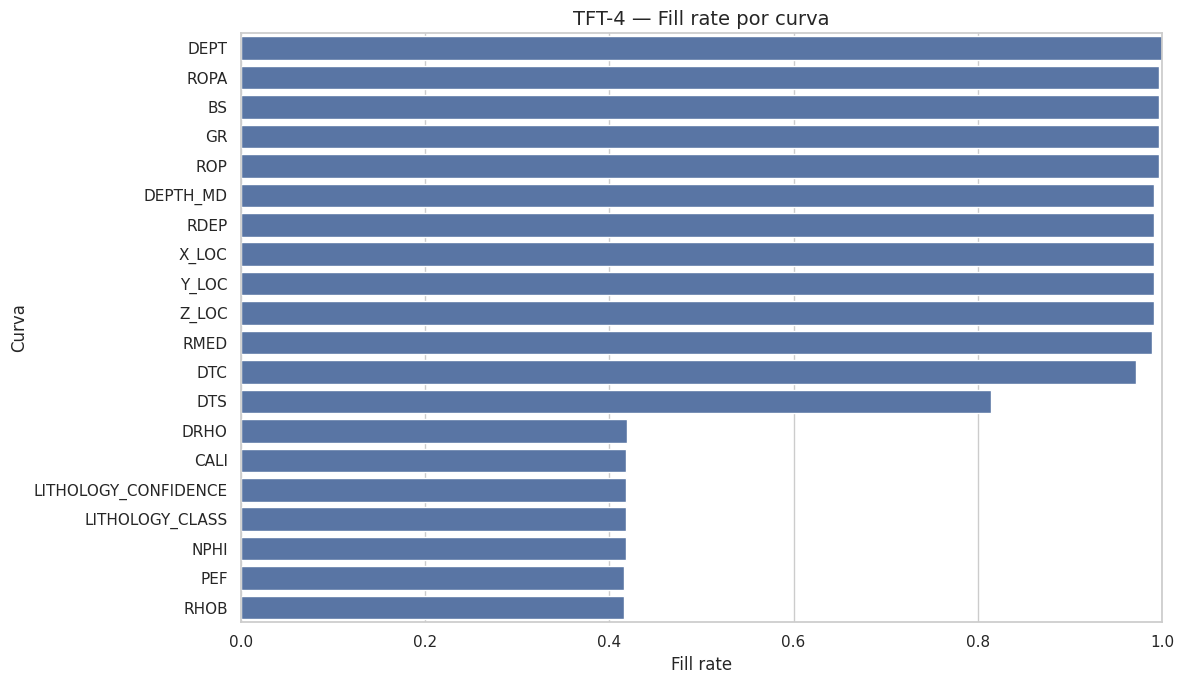

In [6]:
# ============================================================
# STEP 3 — CURVE INVENTORY
# ============================================================

def build_curve_inventory(df: pd.DataFrame, curve_header_df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    cols = [c for c in df.columns if c != "WELL"]

    base = pd.DataFrame({
        "CURVE": cols,
        "NON_NULL_COUNT": df[cols].notna().sum().values,
        "NULL_COUNT": df[cols].isna().sum().values,
        "FILL_RATE": df[cols].notna().mean().values,
        "NULL_RATE": df[cols].isna().mean().values,
        "UNIQUE_VALUES": df[cols].nunique(dropna=True).values,
        "TOTAL_ROWS": total_rows,
    })

    units = (
        curve_header_df[["MNEMONIC", "UNIT", "DESCRIPTION"]]
        .rename(columns={"MNEMONIC": "CURVE"})
        .drop_duplicates(subset=["CURVE"])
    )

    return (
        base.merge(units, on="CURVE", how="left")
        .sort_values(["FILL_RATE", "CURVE"], ascending=[False, True])
        .reset_index(drop=True)
    )

curve_inventory_df = build_curve_inventory(raw_df, curve_header_df)
display(curve_inventory_df)
curve_inventory_df.to_csv(REPORT_DIR / f"{WELL_NAME}_curve_inventory.csv", index=False)

plt.figure(figsize=(12, max(6, len(curve_inventory_df) * 0.35)))
sns.barplot(data=curve_inventory_df, y="CURVE", x="FILL_RATE", orient="h")
plt.title(f"{WELL_NAME} — Fill rate por curva")
plt.xlabel("Fill rate")
plt.ylabel("Curva")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# STEP 4 — Depth QC

A profundidade é o eixo estrutural do poço. Verificamos monotonicidade, step, duplicatas e gaps.

,VALUE
DEPTH_COLUMN,DEPT
N_ROWS,18731
DEPTH_NON_NULL,18731
DEPTH_NULL,0
DEPTH_MIN,372.008400
DEPTH_MAX,"3,218.968400"
DEPTH_RANGE,"2,846.960000"
IS_MONOTONIC_INCREASING,True
DUPLICATED_DEPTH_COUNT,0
NEGATIVE_OR_ZERO_STEPS,0


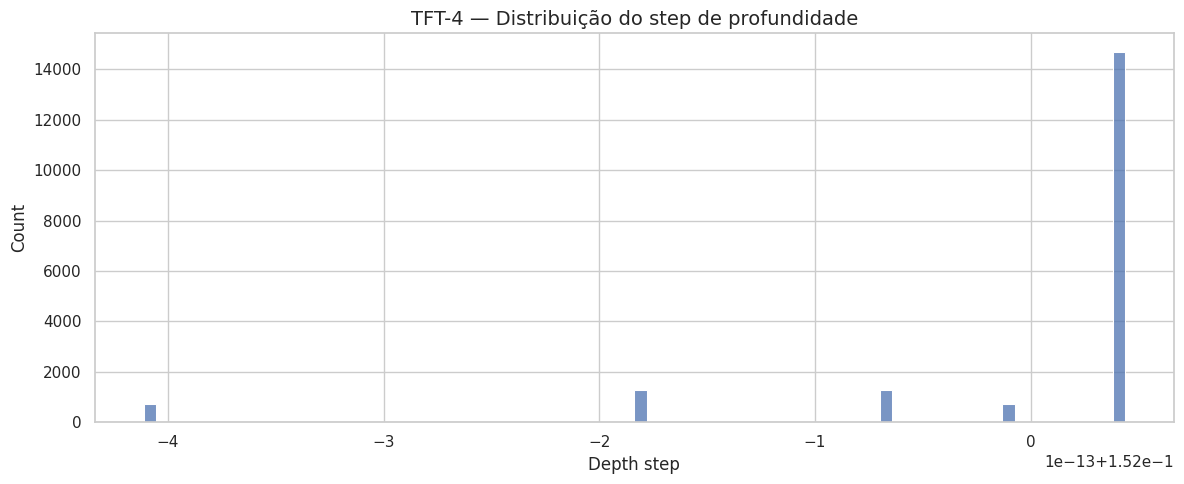

Step mediano: 0.15200000000004366
Threshold de gap: 0.45600000000013097
Gaps detectados: 0


,PREVIOUS_DEPTH,CURRENT_DEPTH,GAP_SIZE


In [7]:
# ============================================================
# STEP 4 — DEPTH QC
# ============================================================

DEPTH_CANDIDATES = ["DEPTH", "DEPT", "DEPTH_MD", "MD"]

def detect_depth_column(df: pd.DataFrame) -> str:
    existing = [c for c in DEPTH_CANDIDATES if c in df.columns]
    if not existing:
        raise ValueError(f"Nenhuma coluna de profundidade encontrada: {DEPTH_CANDIDATES}")
    for preferred in ["DEPT", "DEPTH_MD", "DEPTH", "MD"]:
        if preferred in existing:
            return preferred
    return existing[0]

depth_col_raw = detect_depth_column(raw_df)
depth_series = pd.to_numeric(raw_df[depth_col_raw], errors="coerce")
depth_diff = depth_series.diff()
positive_steps = depth_diff[depth_diff > 0].dropna()

depth_qc = {
    "DEPTH_COLUMN": depth_col_raw,
    "N_ROWS": len(raw_df),
    "DEPTH_NON_NULL": depth_series.notna().sum(),
    "DEPTH_NULL": depth_series.isna().sum(),
    "DEPTH_MIN": depth_series.min(),
    "DEPTH_MAX": depth_series.max(),
    "DEPTH_RANGE": depth_series.max() - depth_series.min(),
    "IS_MONOTONIC_INCREASING": depth_series.is_monotonic_increasing,
    "DUPLICATED_DEPTH_COUNT": depth_series.duplicated().sum(),
    "NEGATIVE_OR_ZERO_STEPS": (depth_diff <= 0).sum(),
    "MEDIAN_STEP": positive_steps.median(),
    "MEAN_STEP": positive_steps.mean(),
    "MIN_POSITIVE_STEP": positive_steps.min(),
    "MAX_POSITIVE_STEP": positive_steps.max(),
    "STEP_STD": positive_steps.std(),
}

depth_qc_df = pd.DataFrame([depth_qc]).T.rename(columns={0: "VALUE"})
display(depth_qc_df)
depth_qc_df.to_csv(REPORT_DIR / f"{WELL_NAME}_depth_qc.csv")

plt.figure(figsize=(12, 5))
sns.histplot(positive_steps, bins=80)
plt.title(f"{WELL_NAME} — Distribuição do step de profundidade")
plt.xlabel("Depth step")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

median_step = positive_steps.median()
gap_threshold = median_step * 3
gap_mask = depth_diff > gap_threshold

gaps_df = pd.DataFrame({
    "PREVIOUS_DEPTH": depth_series.shift(1).loc[gap_mask],
    "CURRENT_DEPTH": depth_series.loc[gap_mask],
    "GAP_SIZE": depth_diff.loc[gap_mask],
}).reset_index(drop=True)

print(f"Step mediano: {median_step}")
print(f"Threshold de gap: {gap_threshold}")
print(f"Gaps detectados: {len(gaps_df)}")
display(gaps_df.head(50))
gaps_df.to_csv(REPORT_DIR / f"{WELL_NAME}_depth_gaps.csv", index=False)

# STEP 5 — Unit QC

Validamos unidades declaradas para evitar erros graves em cálculos posteriores.

In [8]:
# ============================================================
# STEP 5 — UNIT QC
# ============================================================

EXPECTED_UNITS = {
    "DEPTH": ["m", "meter", "meters", "ft", "feet", ""],
    "DEPT": ["m", "meter", "meters", "ft", "feet", ""],
    "DEPTH_MD": ["m", "meter", "meters", "ft", "feet", ""],
    "GR": ["gapi", "api", ""],
    "RHOB": ["g/cm3", "g/cm³", "g/cc", ""],
    "DTC": ["us/ft", "µs/ft", "usec/ft", ""],
    "DTS": ["us/ft", "µs/ft", "usec/ft", ""],
    "NPHI": ["m3/m3", "v/v", "frac", ""],
    "RDEP": ["ohm.m", "ohmm", "ohm-m", ""],
    "RMED": ["ohm.m", "ohmm", "ohm-m", ""],
    "RSHA": ["ohm.m", "ohmm", "ohm-m", ""],
    "CALI": ["in", "inch", "inches", ""],
    "BS": ["in", "inch", "inches", ""],
}

def normalize_unit(unit: object) -> str:
    if pd.isna(unit):
        return ""
    return str(unit).strip().lower().replace(" ", "")

unit_qc_df = curve_inventory_df[["CURVE", "UNIT", "DESCRIPTION"]].copy()
unit_qc_df["UNIT_NORMALIZED"] = unit_qc_df["UNIT"].map(normalize_unit)

def unit_status(row: pd.Series) -> str:
    curve = row["CURVE"]
    unit = row["UNIT_NORMALIZED"]
    expected = EXPECTED_UNITS.get(curve)
    if expected is None:
        return "NO_RULE"
    expected_norm = [normalize_unit(u) for u in expected]
    return "OK" if unit in expected_norm else "CHECK_UNIT"

unit_qc_df["UNIT_QC_STATUS"] = unit_qc_df.apply(unit_status, axis=1)
unit_qc_df["EXPECTED_UNITS"] = unit_qc_df["CURVE"].map(lambda c: EXPECTED_UNITS.get(c, []))

display(unit_qc_df.sort_values(["UNIT_QC_STATUS", "CURVE"]))
unit_qc_df.to_csv(REPORT_DIR / f"{WELL_NAME}_unit_qc.csv", index=False)

,CURVE,UNIT,DESCRIPTION,UNIT_NORMALIZED,UNIT_QC_STATUS,EXPECTED_UNITS
5,DEPTH_MD,_,DEPTH_MD,_,CHECK_UNIT,"[m, meter, meters, ft, feet, ]"
13,DRHO,g/cm3,DRHO,g/cm3,NO_RULE,[]
16,LITHOLOGY_CLASS,_,LITHOLOGY_CLASS,_,NO_RULE,[]
15,LITHOLOGY_CONFIDENCE,_,LITHOLOGY_CONFIDENCE,_,NO_RULE,[]
18,PEF,b/e,PEF,b/e,NO_RULE,[]
4,ROP,m/h,ROP,m/h,NO_RULE,[]
1,ROPA,_,ROPA,_,NO_RULE,[]
7,X_LOC,_,x_loc,_,NO_RULE,[]
8,Y_LOC,_,y_loc,_,NO_RULE,[]
9,Z_LOC,_,z_loc,_,NO_RULE,[]


# STEP 6 — Raw Data Overview

Visão geral da bagunça inicial: shape, tipos, estatísticas, nulos e logs rápidos.

Shape bruto:
(18731, 21)
<class 'pandas.DataFrame'>
RangeIndex: 18731 entries, 0 to 18730
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DEPT                  18731 non-null  float64
 1   LITHOLOGY_CONFIDENCE  7841 non-null   float64
 2   LITHOLOGY_CLASS       7840 non-null   float64
 3   CALI                  7842 non-null   float64
 4   BS                    18674 non-null  float64
 5   ROPA                  18680 non-null  float64
 6   ROP                   18664 non-null  float64
 7   RDEP                  18567 non-null  float64
 8   RMED                  18524 non-null  float64
 9   DTS                   15252 non-null  float64
 10  DTC                   18199 non-null  float64
 11  NPHI                  7835 non-null   float64
 12  PEF                   7800 non-null   float64
 13  GR                    18666 non-null  float64
 14  RHOB                  7800 non-null   float64
 15  DRHO 

,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,WELL
0,372.008400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
1,372.160400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
2,372.312400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
3,372.464400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
4,372.616400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4


,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,WELL
18726,"3,218.360400",NaN,NaN,NaN,NaN,32.203064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18727,"3,218.512400",NaN,NaN,NaN,NaN,28.998888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18728,"3,218.664400",NaN,NaN,NaN,NaN,25.799675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18729,"3,218.816400",NaN,NaN,NaN,NaN,22.596163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18730,"3,218.968400",NaN,NaN,NaN,NaN,19.393373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4


,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.9%,max
DEPT,"18,731.000000","1,795.488400",821.912379,372.008400,374.855360,400.478000,514.356400,"1,083.748400","1,795.488400","2,507.228400","3,076.620400","3,190.498800","3,216.121440","3,218.968400"
LITHOLOGY_CONFIDENCE,"7,841.000000",1.007014,0.083463,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
LITHOLOGY_CLASS,"7,840.000000","59,116.639031","14,172.895337","30,000.000000","30,000.000000","30,000.000000","30,000.000000","65,000.000000","65,000.000000","65,000.000000","70,000.000000","80,000.000000","90,000.000000","90,000.000000"
CALI,"7,842.000000",8.645759,0.354859,8.350532,8.390722,8.419390,8.445753,8.485698,8.536774,8.642059,9.308144,9.766054,12.264491,12.631611
BS,"18,674.000000",10.187998,1.687491,8.500000,8.500000,8.500000,8.500000,8.500000,9.875000,12.250001,12.250001,12.250001,12.250001,12.250001
ROPA,"18,680.000000",31.640796,21.722386,0.712413,1.213201,2.215831,6.050115,17.168622,28.252594,43.528939,60.972892,75.846709,249.506674,360.433502
ROP,"18,664.000000",30.832899,22.168637,0.000000,0.000000,1.143180,5.262480,16.759844,27.777618,42.716022,62.732954,79.858044,136.131263,"1,270.482178"
RDEP,"18,567.000000",2.620270,10.496727,0.196063,0.419793,0.524593,0.637572,0.962309,1.429376,3.237903,5.879056,10.935951,44.290838,"1,122.036377"
RMED,"18,524.000000",2.552476,8.401663,0.218748,0.296669,0.519098,0.623631,0.942606,1.405266,3.178944,5.604294,11.438138,40.202075,679.883728
DTS,"15,252.000000",265.417520,112.633809,86.628220,94.507664,116.473900,133.747711,154.378006,245.879082,378.433235,417.216252,428.729909,438.926384,448.593384


,NULL_RATE,FILL_RATE
PEF,0.583578,0.416422
RHOB,0.583578,0.416422
NPHI,0.581709,0.418291
LITHOLOGY_CLASS,0.581443,0.418557
LITHOLOGY_CONFIDENCE,0.581389,0.418611
CALI,0.581336,0.418664
DRHO,0.581122,0.418878
DTS,0.185735,0.814265
DTC,0.028402,0.971598
RMED,0.011051,0.988949


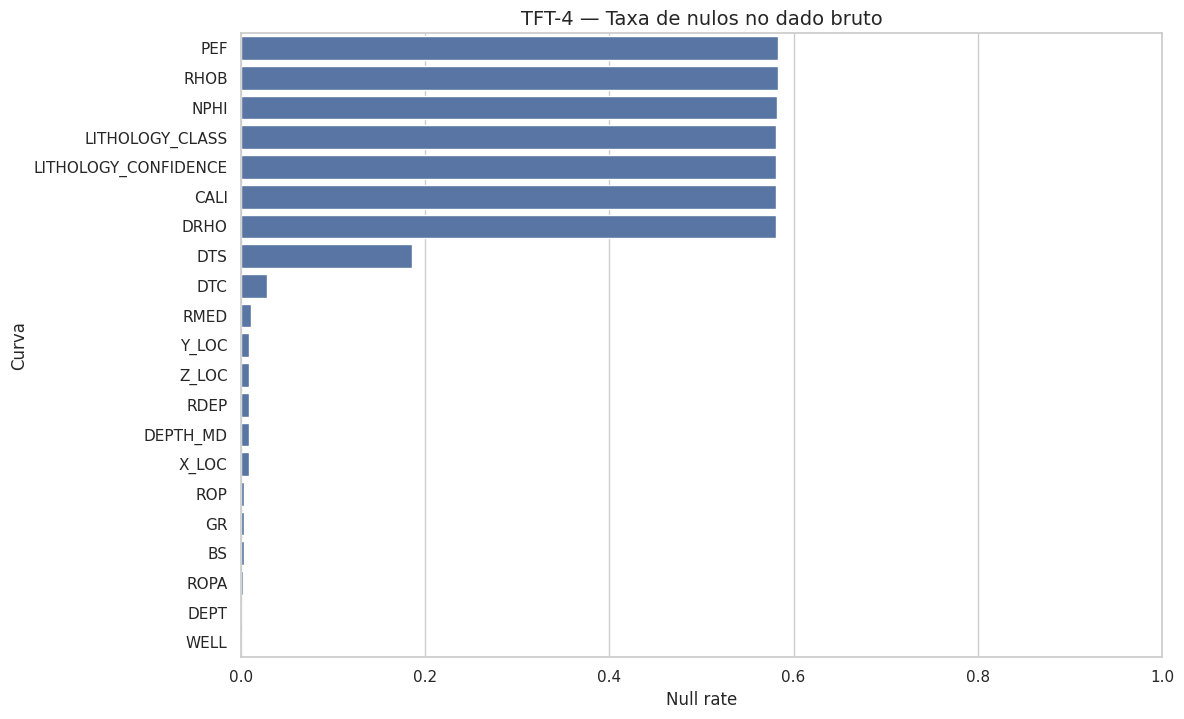

In [9]:
# ============================================================
# STEP 6 — RAW DATA OVERVIEW
# ============================================================

print("Shape bruto:")
print(raw_df.shape)
raw_df.info()

display(raw_df.head())
display(raw_df.tail())
display(raw_df.describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]).T)

raw_null_rate = raw_df.isna().mean().sort_values(ascending=False).rename("NULL_RATE").to_frame()
raw_null_rate["FILL_RATE"] = 1 - raw_null_rate["NULL_RATE"]
display(raw_null_rate)

plt.figure(figsize=(12, max(5, len(raw_null_rate) * 0.35)))
sns.barplot(data=raw_null_rate.reset_index().rename(columns={"index": "CURVE"}), y="CURVE", x="NULL_RATE", orient="h")
plt.title(f"{WELL_NAME} — Taxa de nulos no dado bruto")
plt.xlabel("Null rate")
plt.ylabel("Curva")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

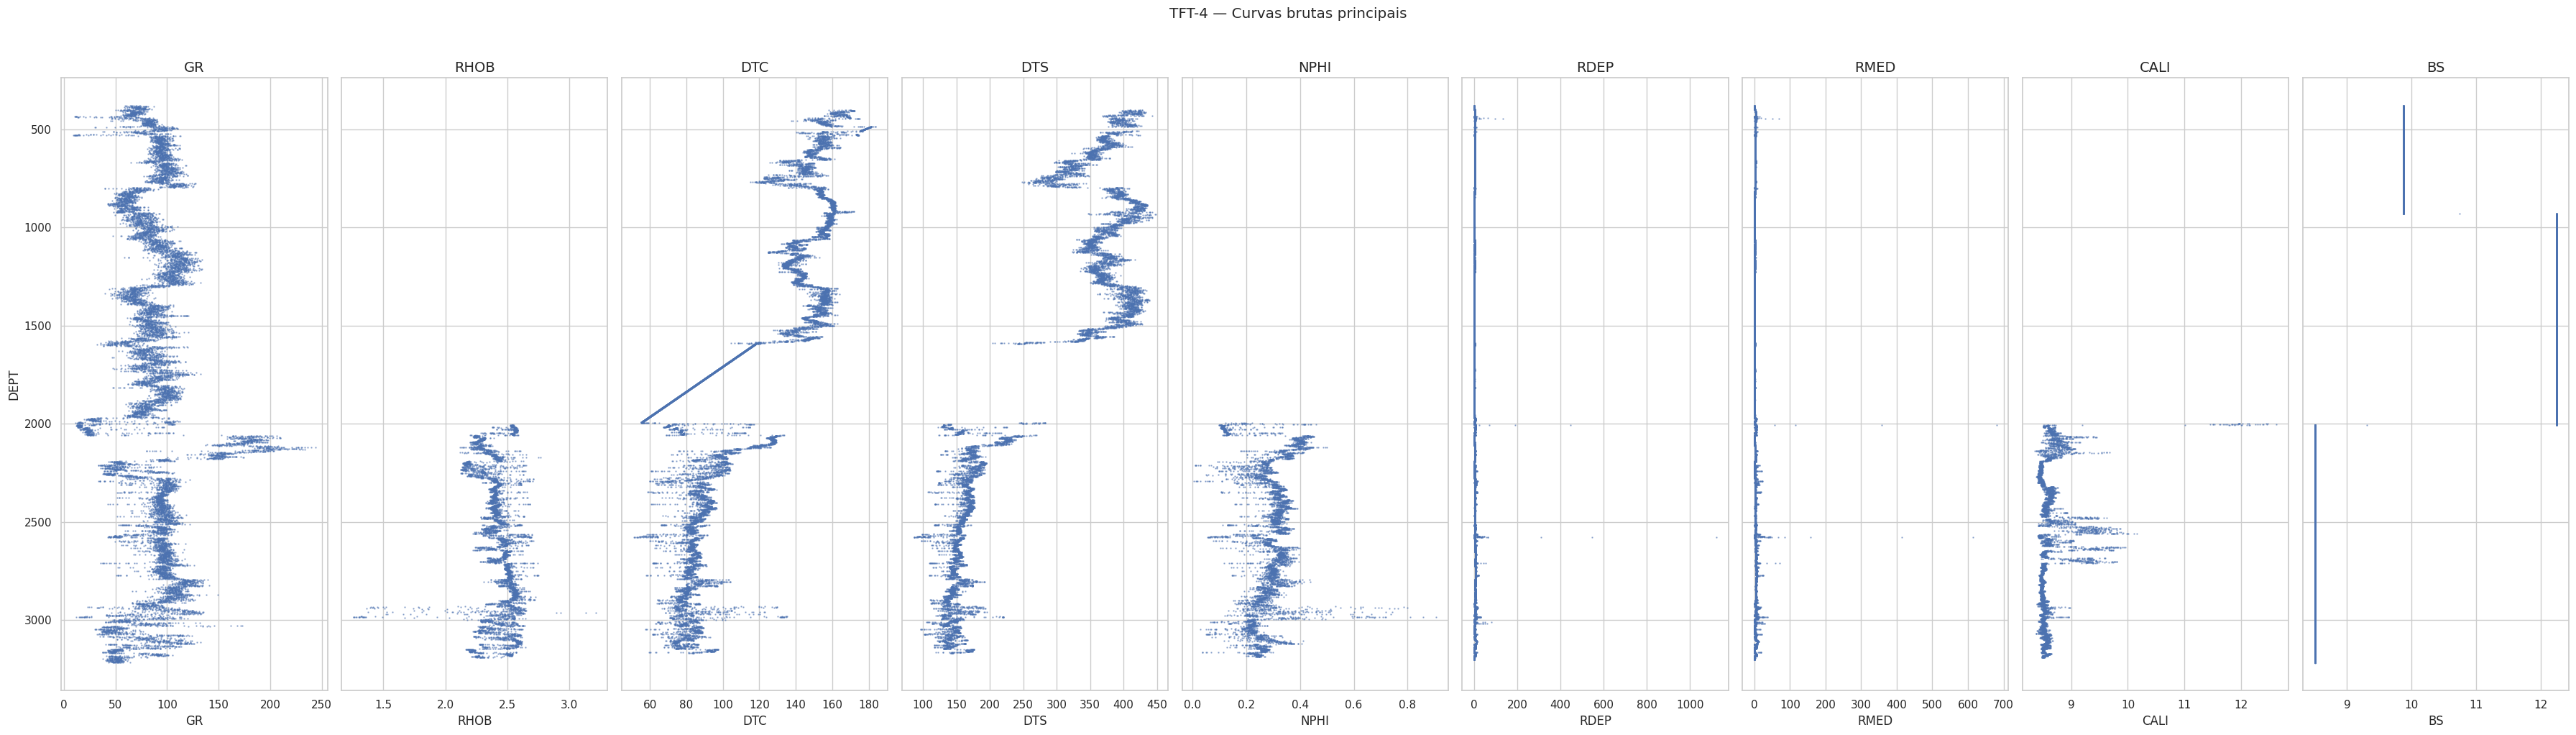

In [10]:
# ============================================================
# STEP 6.1 — QUICK LOG PLOT
# ============================================================

def plot_log_curves(df: pd.DataFrame, depth_col: str, curves: List[str], title: str, max_points: int = 30_000) -> None:
    existing_curves = [c for c in curves if c in df.columns]
    if not existing_curves:
        print("Nenhuma curva solicitada existe no DataFrame.")
        return

    plot_df = df[[depth_col] + existing_curves].dropna(subset=[depth_col]).copy()
    if len(plot_df) > max_points:
        step = max(1, len(plot_df) // max_points)
        plot_df = plot_df.iloc[::step].copy()

    n = len(existing_curves)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 10), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, curve in zip(axes, existing_curves):
        ax.plot(plot_df[curve], plot_df[depth_col], ".", markersize=1.5, alpha=0.5)
        ax.set_title(curve)
        ax.set_xlabel(curve)

    axes[0].invert_yaxis()
    axes[0].set_ylabel(depth_col)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

main_curves = ["GR", "RHOB", "DTC", "DTS", "NPHI", "RDEP", "RMED", "CALI", "BS"]
plot_log_curves(raw_df, depth_col_raw, main_curves, f"{WELL_NAME} — Curvas brutas principais")

# STEP 7 — Standardization

Padronizamos nomes, tipos e estrutura. Aqui `DEPT`, `DEPTH_MD` e `MD` convergem para `DEPTH`; `NPHI` converge para `NPOR`.

In [11]:
# ============================================================
# STEP 7 — STANDARDIZATION
# ============================================================

COLUMN_MAPPING = {
    "DEPT": "DEPTH",
    "DEPTH_MD": "DEPTH",
    "MD": "DEPTH",
    "NPHI": "NPOR",
    "PHIN": "NPOR",
    "ILD": "RDEP",
    "RT": "RDEP",
    "ILM": "RMED",
    "LLS": "RSHA",
}

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = (
        pd.Index(out.columns)
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "_", regex=False)
    )
    out = out.rename(columns=COLUMN_MAPPING)

    duplicated_names = out.columns[out.columns.duplicated()].unique().tolist()
    for col in duplicated_names:
        same_cols = out.loc[:, out.columns == col]
        consolidated = same_cols.bfill(axis=1).iloc[:, 0]
        out = out.loc[:, out.columns != col]
        out[col] = consolidated

    if "WELL" not in out.columns:
        out["WELL"] = WELL_NAME

    for col in out.columns:
        if col != "WELL":
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "DEPTH" not in out.columns:
        raise ValueError("Coluna DEPTH não encontrada após padronização.")

    return out.sort_values("DEPTH").reset_index(drop=True)

std_df = standardize_columns(raw_df)
print(f"Shape após padronização: {std_df.shape}")
print(std_df.columns.tolist())
display(std_df.head())

Shape após padronização: (18731, 20)
['LITHOLOGY_CONFIDENCE', 'LITHOLOGY_CLASS', 'CALI', 'BS', 'ROPA', 'ROP', 'RDEP', 'RMED', 'DTS', 'DTC', 'NPOR', 'PEF', 'GR', 'RHOB', 'DRHO', 'X_LOC', 'Y_LOC', 'Z_LOC', 'WELL', 'DEPTH']


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,WELL,DEPTH
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.008400
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.160400
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.312400
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.464400
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.616400


# STEP 8 — Invalid Values

Substituímos placeholders clássicos de LAS por `NaN`.

In [12]:
# ============================================================
# STEP 8 — INVALID VALUES
# ============================================================

INVALID_PLACEHOLDERS = [-999.25, -999.0, -999.9, -999.90, -999.900024, -9999.0, -99999.0, -999.250122]

def replace_invalid_placeholders(df: pd.DataFrame, invalid_values: List[float]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()

    invalid_counts = (
        out[numeric_cols]
        .isin(invalid_values)
        .sum()
        .sort_values(ascending=False)
        .rename("INVALID_PLACEHOLDER_COUNT")
        .to_frame()
    )
    invalid_counts = invalid_counts[invalid_counts["INVALID_PLACEHOLDER_COUNT"] > 0]
    out[numeric_cols] = out[numeric_cols].replace(invalid_values, np.nan)
    return out, invalid_counts

clean_step8_df, invalid_counts_df = replace_invalid_placeholders(std_df, INVALID_PLACEHOLDERS)
display(invalid_counts_df)
invalid_counts_df.to_csv(REPORT_DIR / f"{WELL_NAME}_invalid_placeholder_counts.csv")

,INVALID_PLACEHOLDER_COUNT


# STEP 9 — Null Analysis

Analisamos nulos após o tratamento de placeholders. Nulos não são necessariamente erro; podem indicar curva ausente ou trecho não adquirido.

,NON_NULL_COUNT,NULL_COUNT,FILL_RATE,NULL_RATE,TOTAL_ROWS
RHOB,7800,10931,0.416422,0.583578,18731
PEF,7800,10931,0.416422,0.583578,18731
NPOR,7835,10896,0.418291,0.581709,18731
LITHOLOGY_CLASS,7840,10891,0.418557,0.581443,18731
LITHOLOGY_CONFIDENCE,7841,10890,0.418611,0.581389,18731
CALI,7842,10889,0.418664,0.581336,18731
DRHO,7846,10885,0.418878,0.581122,18731
DTS,15252,3479,0.814265,0.185735,18731
DTC,18199,532,0.971598,0.028402,18731
RMED,18524,207,0.988949,0.011051,18731


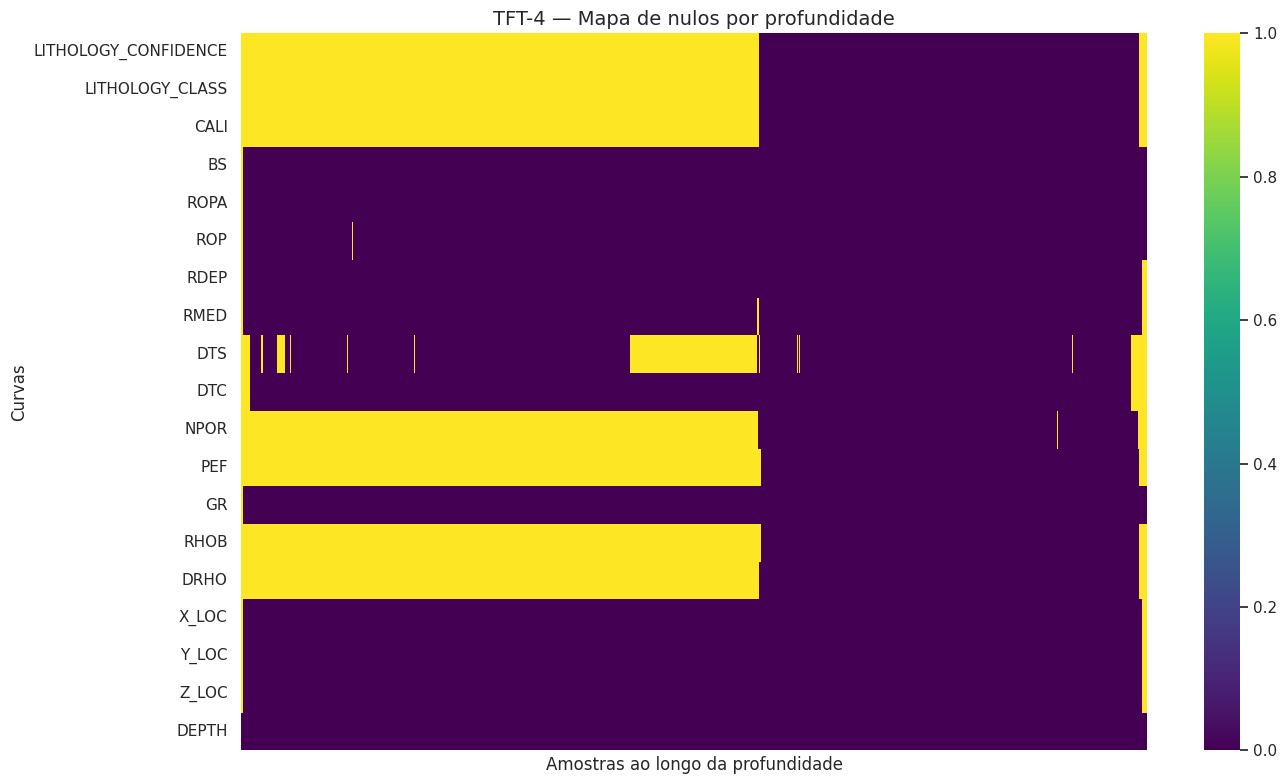

In [13]:
# ============================================================
# STEP 9 — NULL ANALYSIS
# ============================================================

def null_report(df: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        "NON_NULL_COUNT": df.notna().sum(),
        "NULL_COUNT": df.isna().sum(),
        "FILL_RATE": df.notna().mean(),
        "NULL_RATE": df.isna().mean(),
        "TOTAL_ROWS": len(df),
    })
    return report.sort_values("NULL_RATE", ascending=False)

null_report_df = null_report(clean_step8_df)
display(null_report_df)
null_report_df.to_csv(REPORT_DIR / f"{WELL_NAME}_null_report_after_invalid_values.csv")


def plot_null_heatmap(df: pd.DataFrame, max_rows: int = 5_000) -> None:
    plot_cols = [c for c in df.columns if c != "WELL"]
    plot_df = df[plot_cols].copy()
    if len(plot_df) > max_rows:
        step = max(1, len(plot_df) // max_rows)
        plot_df = plot_df.iloc[::step].copy()
    null_matrix = plot_df.isna().astype(int)
    plt.figure(figsize=(14, 8))
    sns.heatmap(null_matrix.T, cbar=True, cmap="viridis", xticklabels=False, yticklabels=True)
    plt.title(f"{WELL_NAME} — Mapa de nulos por profundidade")
    plt.xlabel("Amostras ao longo da profundidade")
    plt.ylabel("Curvas")
    plt.tight_layout()
    plt.show()

plot_null_heatmap(clean_step8_df)

# STEP 10 — Duplicates

Tratamos duplicatas completas e profundidades duplicadas. Para profundidade duplicada, consolidamos por média nas colunas numéricas.

In [14]:
# ============================================================
# STEP 10 — DUPLICATES
# ============================================================

def duplicate_report(df: pd.DataFrame, depth_col: str = "DEPTH"):
    complete_dup_mask = df.duplicated(keep=False)
    depth_dup_mask = df[depth_col].duplicated(keep=False)
    summary = pd.DataFrame([{
        "TOTAL_ROWS": len(df),
        "COMPLETE_DUPLICATED_ROWS": complete_dup_mask.sum(),
        "DUPLICATED_DEPTH_ROWS": depth_dup_mask.sum(),
        "UNIQUE_DEPTHS": df[depth_col].nunique(dropna=True),
    }])
    return summary, df.loc[complete_dup_mask].copy(), df.loc[depth_dup_mask].copy().sort_values(depth_col)

dup_summary_df, complete_dups_df, depth_dups_df = duplicate_report(clean_step8_df, "DEPTH")
display(dup_summary_df)
display(complete_dups_df.head(20))
display(depth_dups_df.head(50))

dup_summary_df.to_csv(REPORT_DIR / f"{WELL_NAME}_duplicate_summary.csv", index=False)
depth_dups_df.to_csv(REPORT_DIR / f"{WELL_NAME}_duplicated_depths.csv", index=False)


def remove_duplicates_controlled(df: pd.DataFrame, depth_col: str = "DEPTH") -> pd.DataFrame:
    out = df.drop_duplicates().copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    non_numeric_cols = [c for c in out.columns if c not in numeric_cols]

    numeric_grouped = out.groupby(depth_col, as_index=False)[numeric_cols].mean()
    if non_numeric_cols:
        non_numeric_grouped = out.groupby(depth_col, as_index=False)[non_numeric_cols].first()
        result = numeric_grouped.merge(non_numeric_grouped, on=depth_col, how="left")
    else:
        result = numeric_grouped
    return result.sort_values(depth_col).reset_index(drop=True)

clean_step10_df = remove_duplicates_controlled(clean_step8_df, "DEPTH")
print(f"Shape antes:  {clean_step8_df.shape}")
print(f"Shape depois: {clean_step10_df.shape}")
print(f"Profundidades duplicadas restantes: {clean_step10_df['DEPTH'].duplicated().sum()}")
display(clean_step10_df.head())

,TOTAL_ROWS,COMPLETE_DUPLICATED_ROWS,DUPLICATED_DEPTH_ROWS,UNIQUE_DEPTHS
0,18731,0,0,18731


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,WELL,DEPTH


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,WELL,DEPTH


Shape antes:  (18731, 20)
Shape depois: (18731, 20)
Profundidades duplicadas restantes: 0


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,DEPTH,WELL
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.008400,TFT-4
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.160400,TFT-4
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.312400,TFT-4
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.464400,TFT-4
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.616400,TFT-4


# STEP 11 — Physical Range QC

Criamos flags físicas para curvas principais. A regra é marcar para investigação, não remover cegamente.

In [15]:
# ============================================================
# STEP 11 — PHYSICAL RANGE QC
# ============================================================

PHYSICAL_RULES = {
    "GR":   {"min": 0.0,   "max": 300.0,  "zero_invalid": False, "description": "Gamma Ray"},
    "RHOB": {"min": 1.5,   "max": 3.0,    "zero_invalid": True,  "description": "Bulk Density"},
    "DTC":  {"min": 40.0,  "max": 200.0,  "zero_invalid": True,  "description": "Compressional Sonic"},
    "DTS":  {"min": 80.0,  "max": 400.0,  "zero_invalid": True,  "description": "Shear Sonic"},
    "NPOR": {"min": -0.15, "max": 0.60,   "zero_invalid": False, "description": "Neutron Porosity"},
    "RDEP": {"min": 0.001, "max": 2000.0, "zero_invalid": True,  "description": "Deep Resistivity"},
    "RMED": {"min": 0.001, "max": 2000.0, "zero_invalid": True,  "description": "Medium Resistivity"},
    "RSHA": {"min": 0.001, "max": 2000.0, "zero_invalid": True,  "description": "Shallow Resistivity"},
    "CALI": {"min": 2.0,   "max": 40.0,   "zero_invalid": True,  "description": "Caliper"},
    "BS":   {"min": 2.0,   "max": 40.0,   "zero_invalid": True,  "description": "Bit Size"},
}

def apply_physical_qc_flags(df: pd.DataFrame, rules: Dict[str, Dict[str, object]]):
    out = df.copy()
    rows = []
    for curve, rule in rules.items():
        if curve not in out.columns:
            continue
        min_v = float(rule["min"])
        max_v = float(rule["max"])
        zero_invalid = bool(rule["zero_invalid"])
        s = out[curve]
        low_flag = s.notna() & (s < min_v)
        high_flag = s.notna() & (s > max_v)
        zero_flag = s.notna() & (s == 0) if zero_invalid else pd.Series(False, index=out.index)
        suspicious = low_flag | high_flag | zero_flag

        out[f"FLAG_{curve}_LOW"] = low_flag
        out[f"FLAG_{curve}_HIGH"] = high_flag
        out[f"FLAG_{curve}_ZERO"] = zero_flag
        out[f"FLAG_{curve}_SUSPICIOUS"] = suspicious

        valid_count = int(s.notna().sum())
        suspicious_count = int(suspicious.sum())
        rows.append({
            "CURVE": curve,
            "DESCRIPTION": rule["description"],
            "MIN_RULE": min_v,
            "MAX_RULE": max_v,
            "ZERO_INVALID": zero_invalid,
            "VALID_COUNT": valid_count,
            "LOW_COUNT": int(low_flag.sum()),
            "HIGH_COUNT": int(high_flag.sum()),
            "ZERO_COUNT": int(zero_flag.sum()),
            "SUSPICIOUS_COUNT": suspicious_count,
            "SUSPICIOUS_RATE_OVER_VALID": suspicious_count / valid_count if valid_count else np.nan,
        })
    return out, pd.DataFrame(rows).sort_values("SUSPICIOUS_RATE_OVER_VALID", ascending=False)

qc_df, physical_qc_summary_df = apply_physical_qc_flags(clean_step10_df, PHYSICAL_RULES)
display(physical_qc_summary_df)
physical_qc_summary_df.to_csv(REPORT_DIR / f"{WELL_NAME}_physical_qc_summary.csv", index=False)

,CURVE,DESCRIPTION,MIN_RULE,MAX_RULE,ZERO_INVALID,VALID_COUNT,LOW_COUNT,HIGH_COUNT,ZERO_COUNT,SUSPICIOUS_COUNT,SUSPICIOUS_RATE_OVER_VALID
3,DTS,Shear Sonic,80.000000,400.000000,True,15252,0,2053,0,2053,0.134605
4,NPOR,Neutron Porosity,-0.150000,0.600000,False,7835,0,41,0,41,0.005233
1,RHOB,Bulk Density,1.500000,3.000000,True,7800,32,2,0,34,0.004359
0,GR,Gamma Ray,0.000000,300.000000,False,18666,0,0,0,0,0.000000
2,DTC,Compressional Sonic,40.000000,200.000000,True,18199,0,0,0,0,0.000000
5,RDEP,Deep Resistivity,0.001000,"2,000.000000",True,18567,0,0,0,0,0.000000
6,RMED,Medium Resistivity,0.001000,"2,000.000000",True,18524,0,0,0,0,0.000000
7,CALI,Caliper,2.000000,40.000000,True,7842,0,0,0,0,0.000000
8,BS,Bit Size,2.000000,40.000000,True,18674,0,0,0,0,0.000000


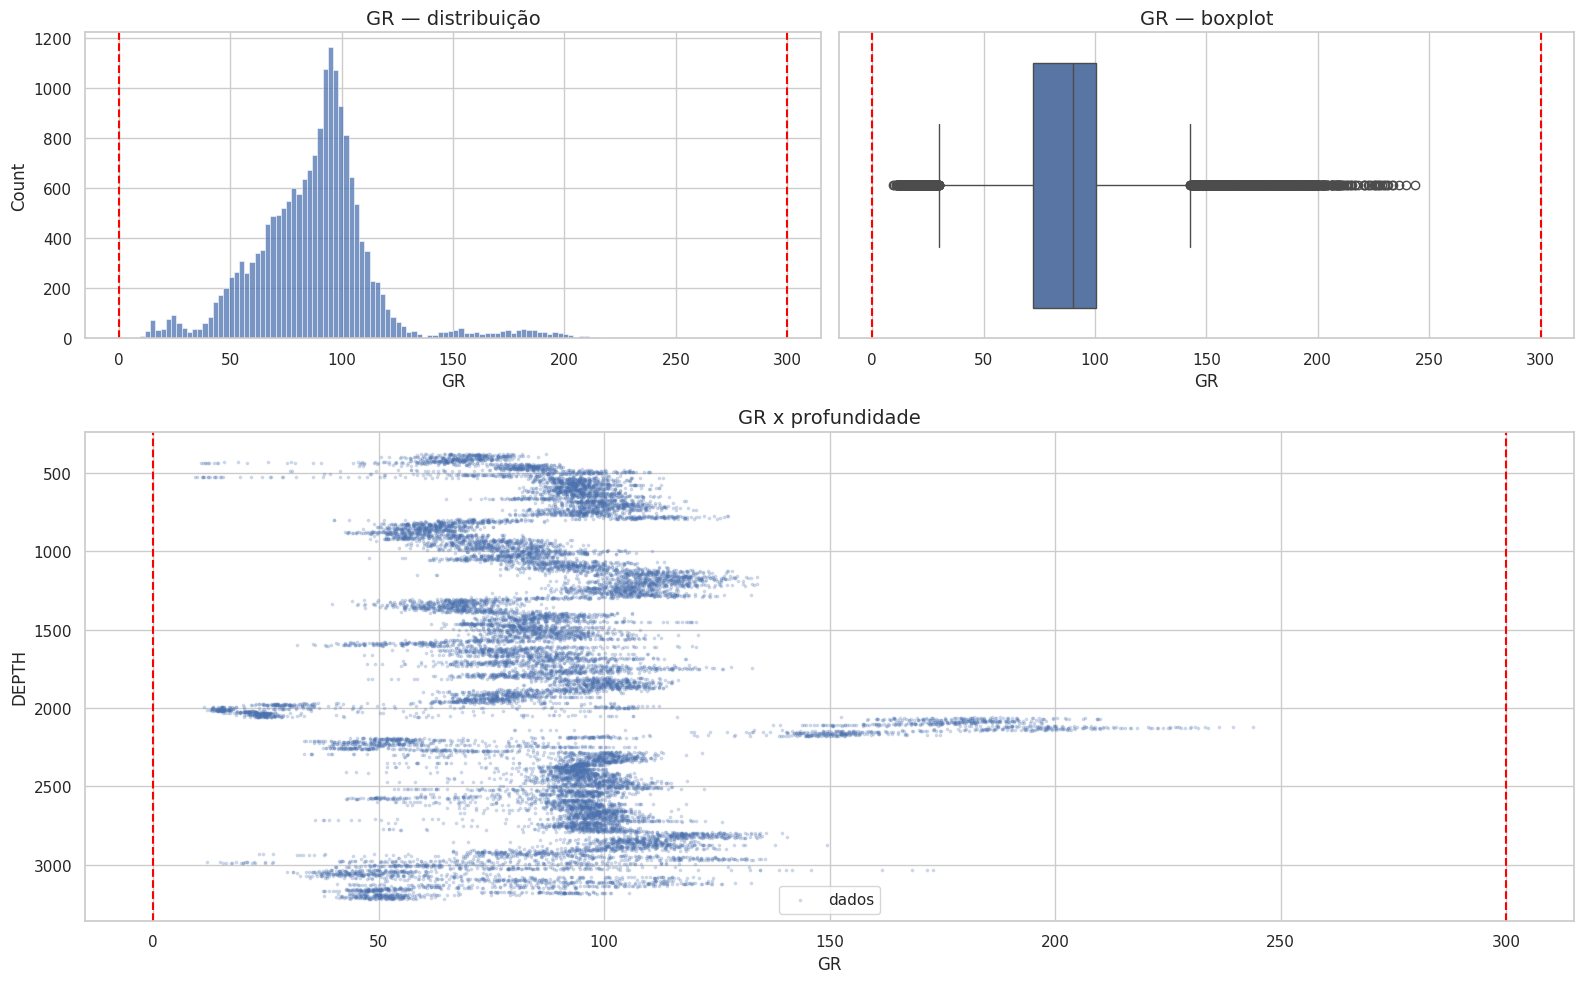

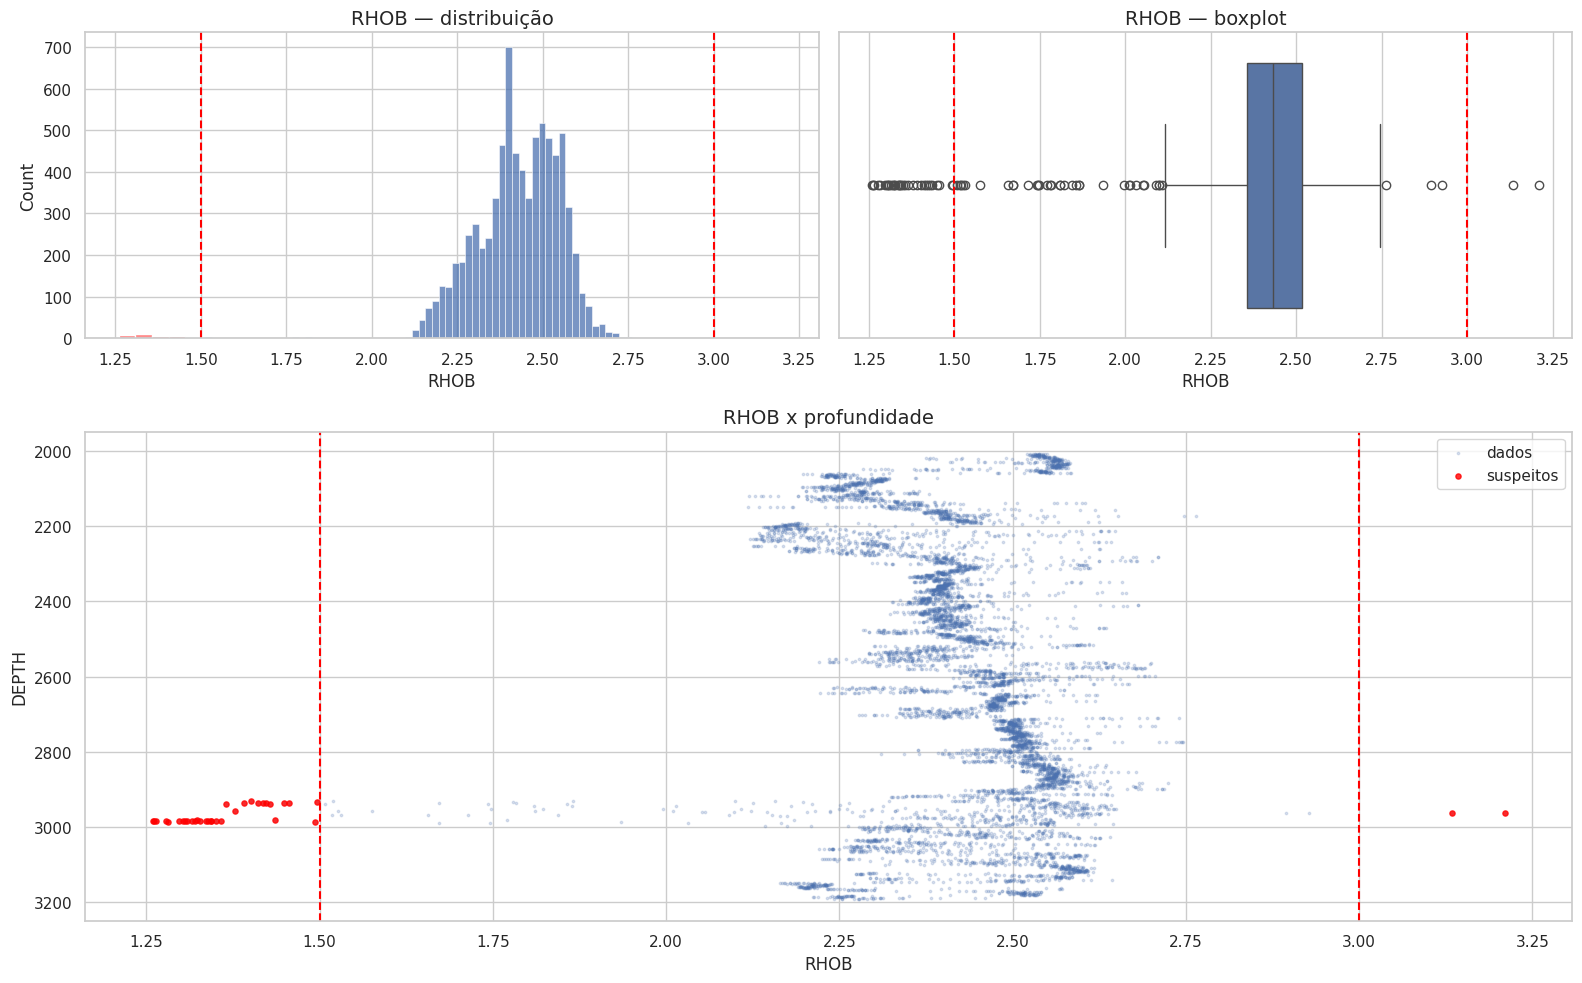

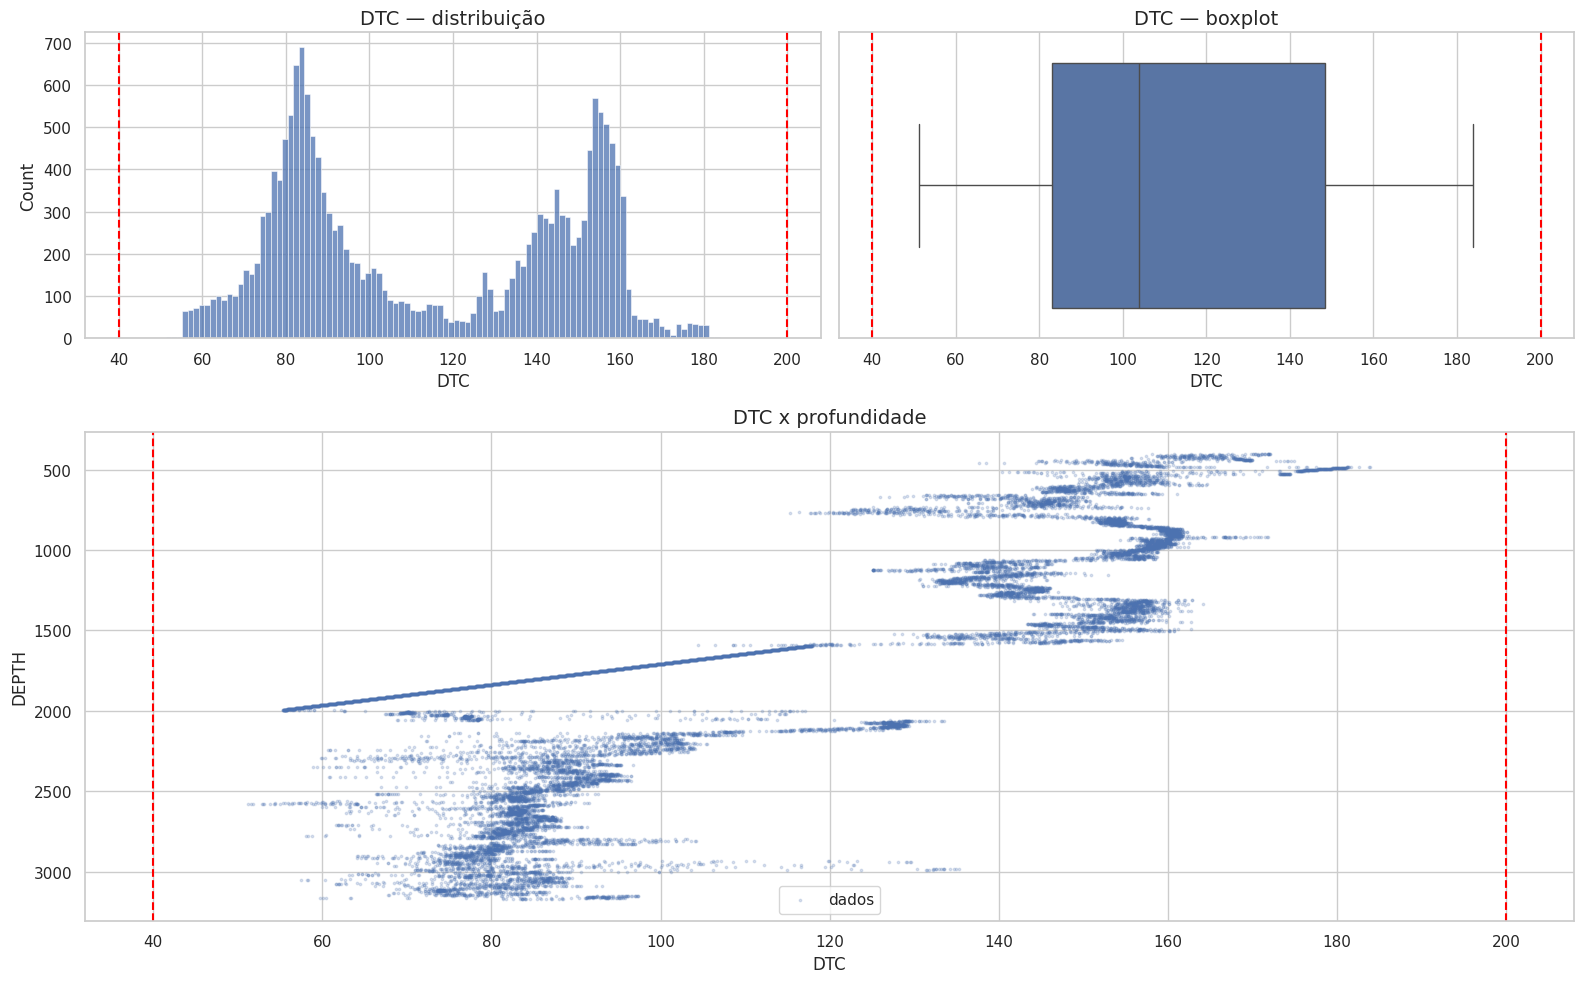

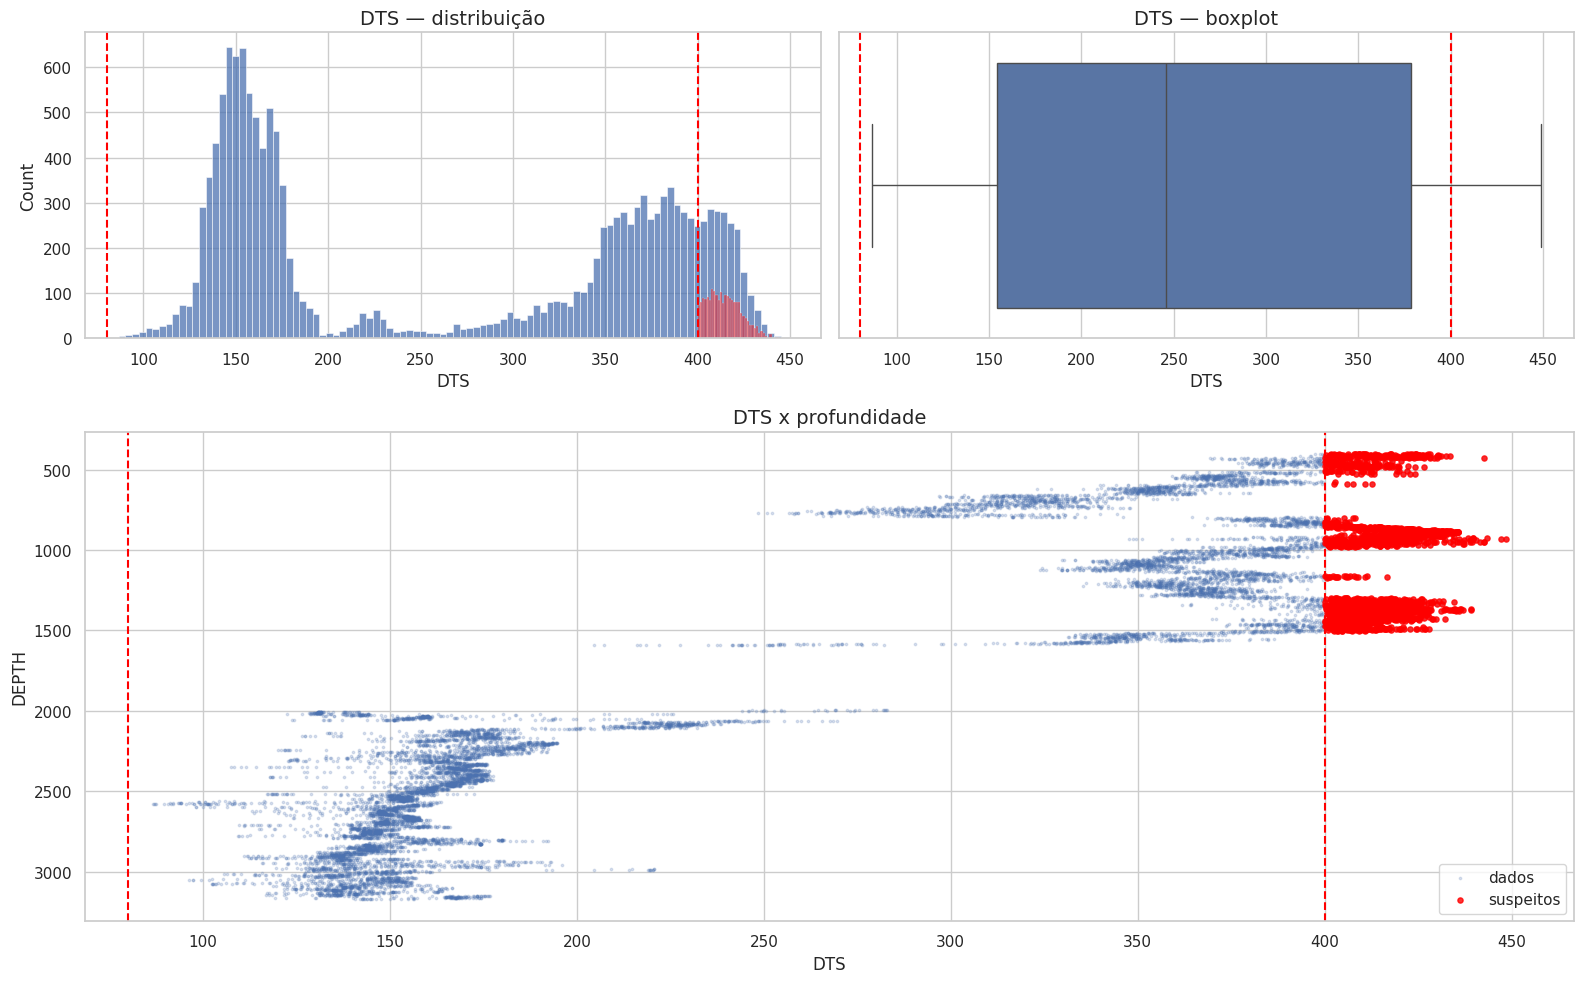

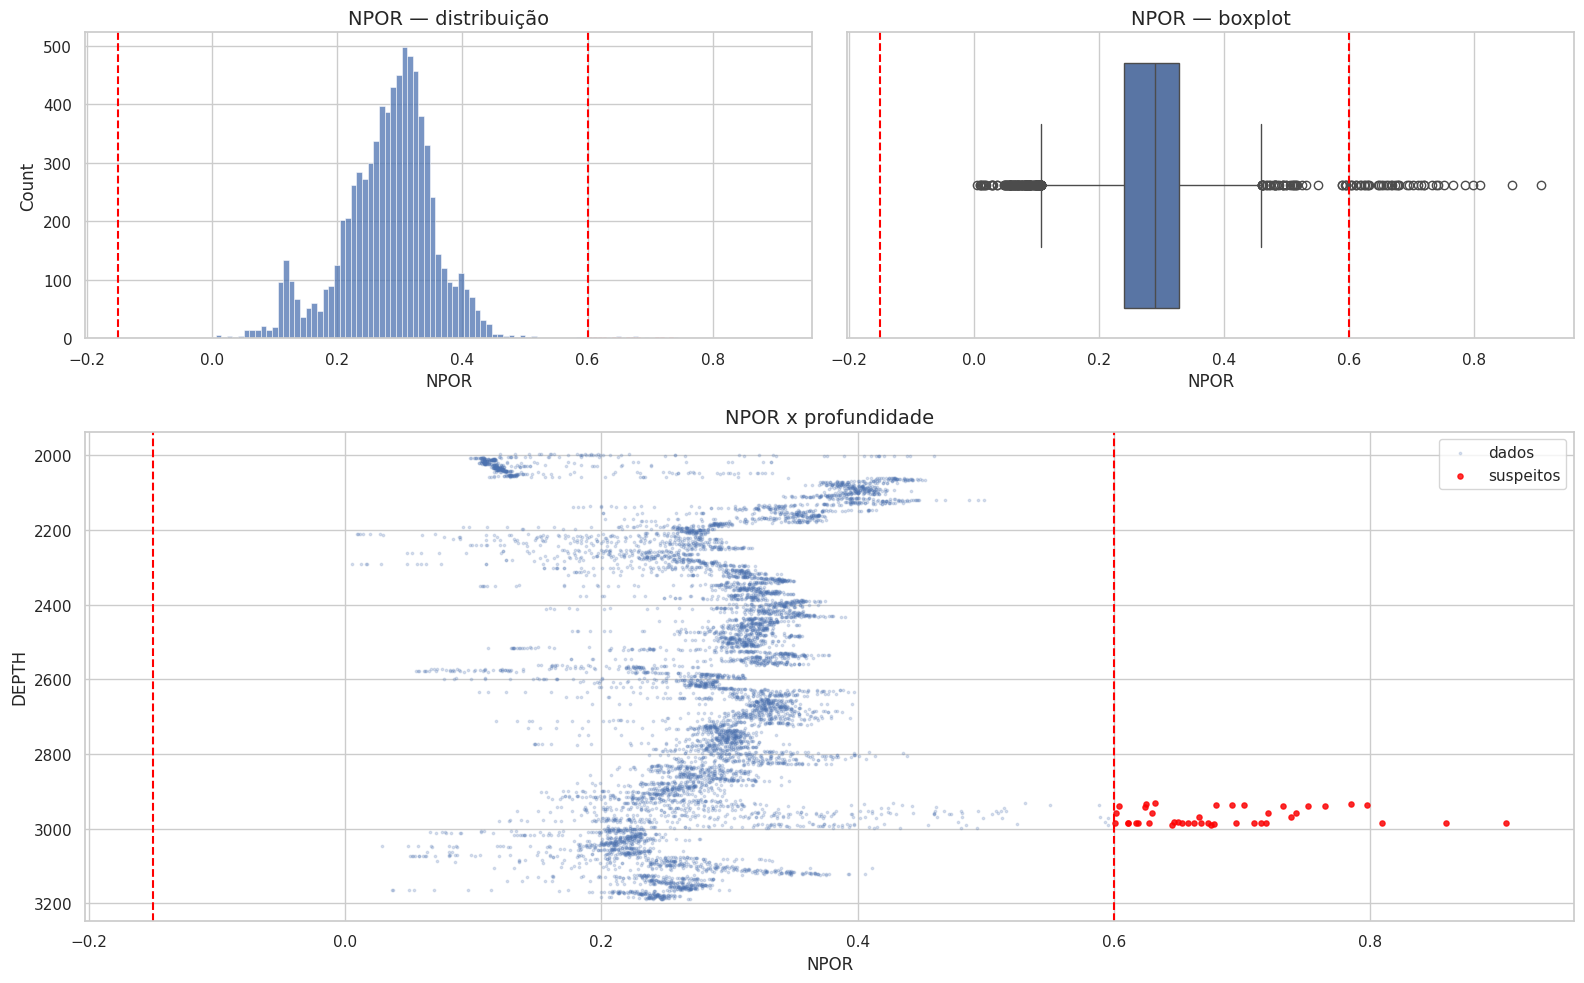

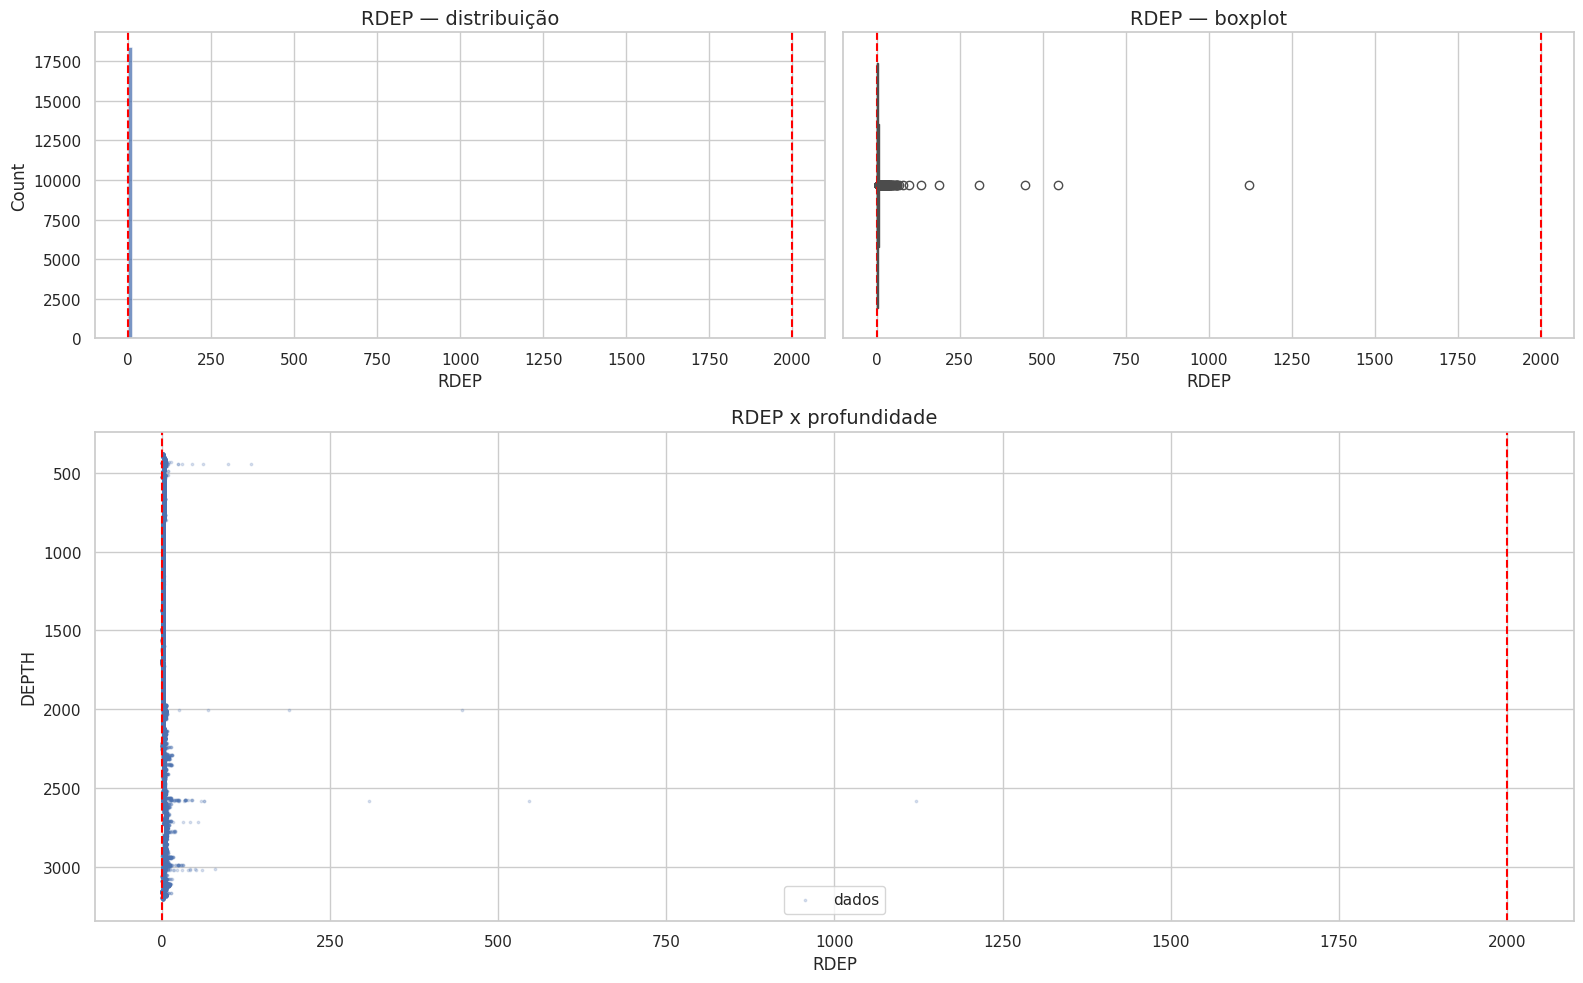

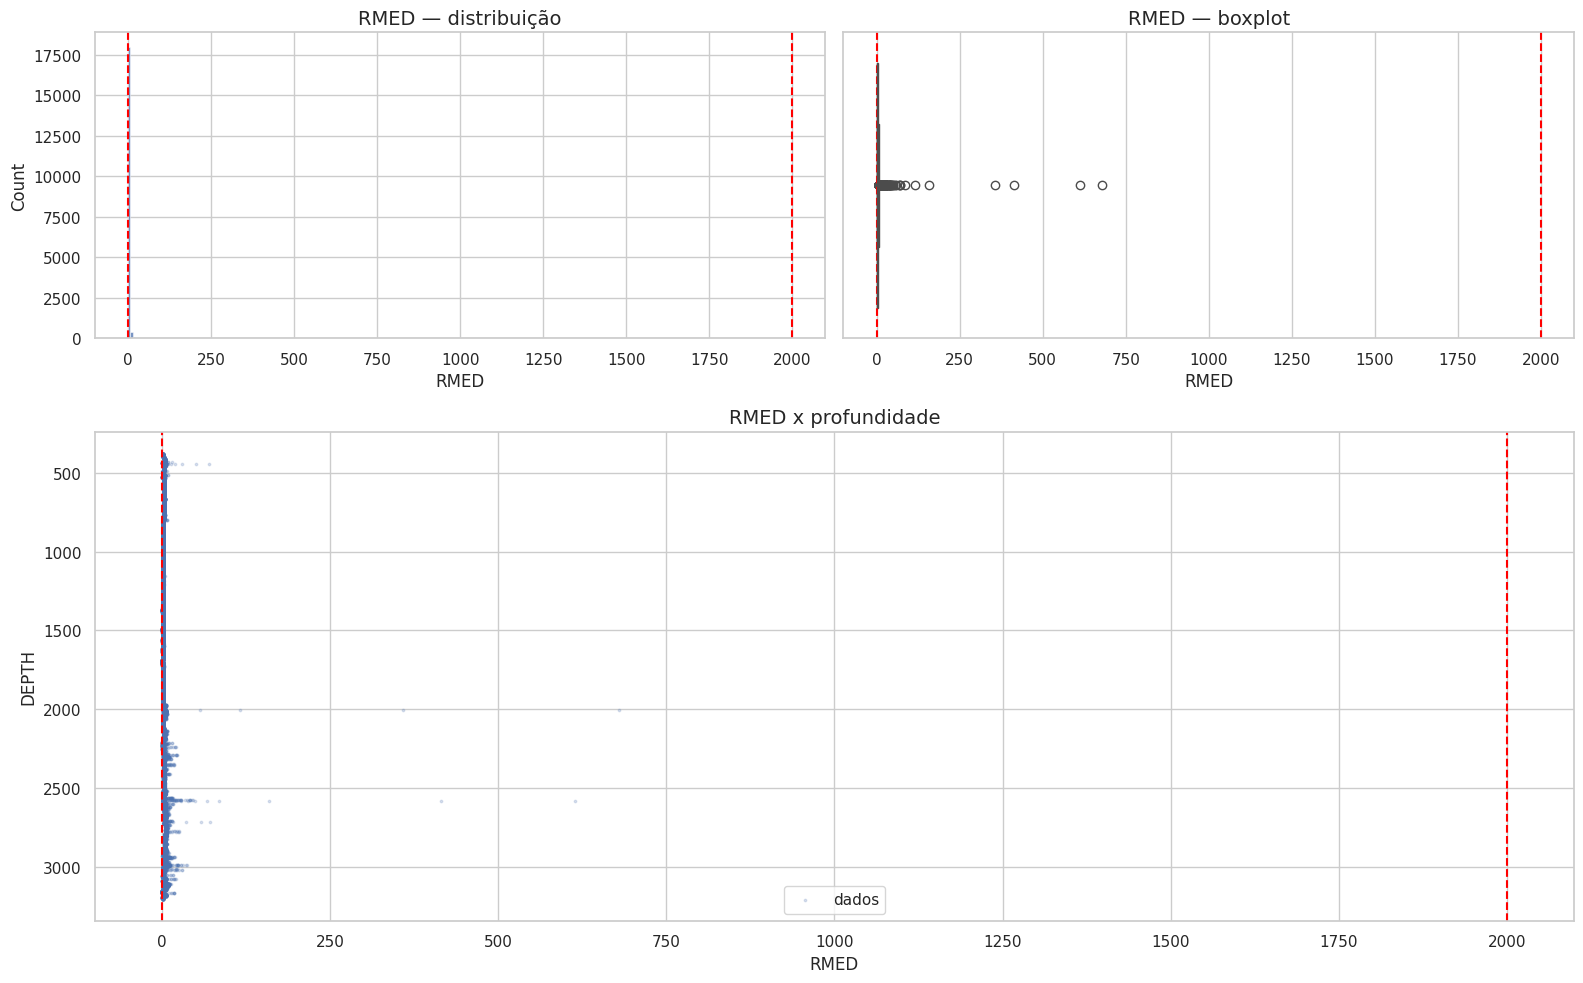

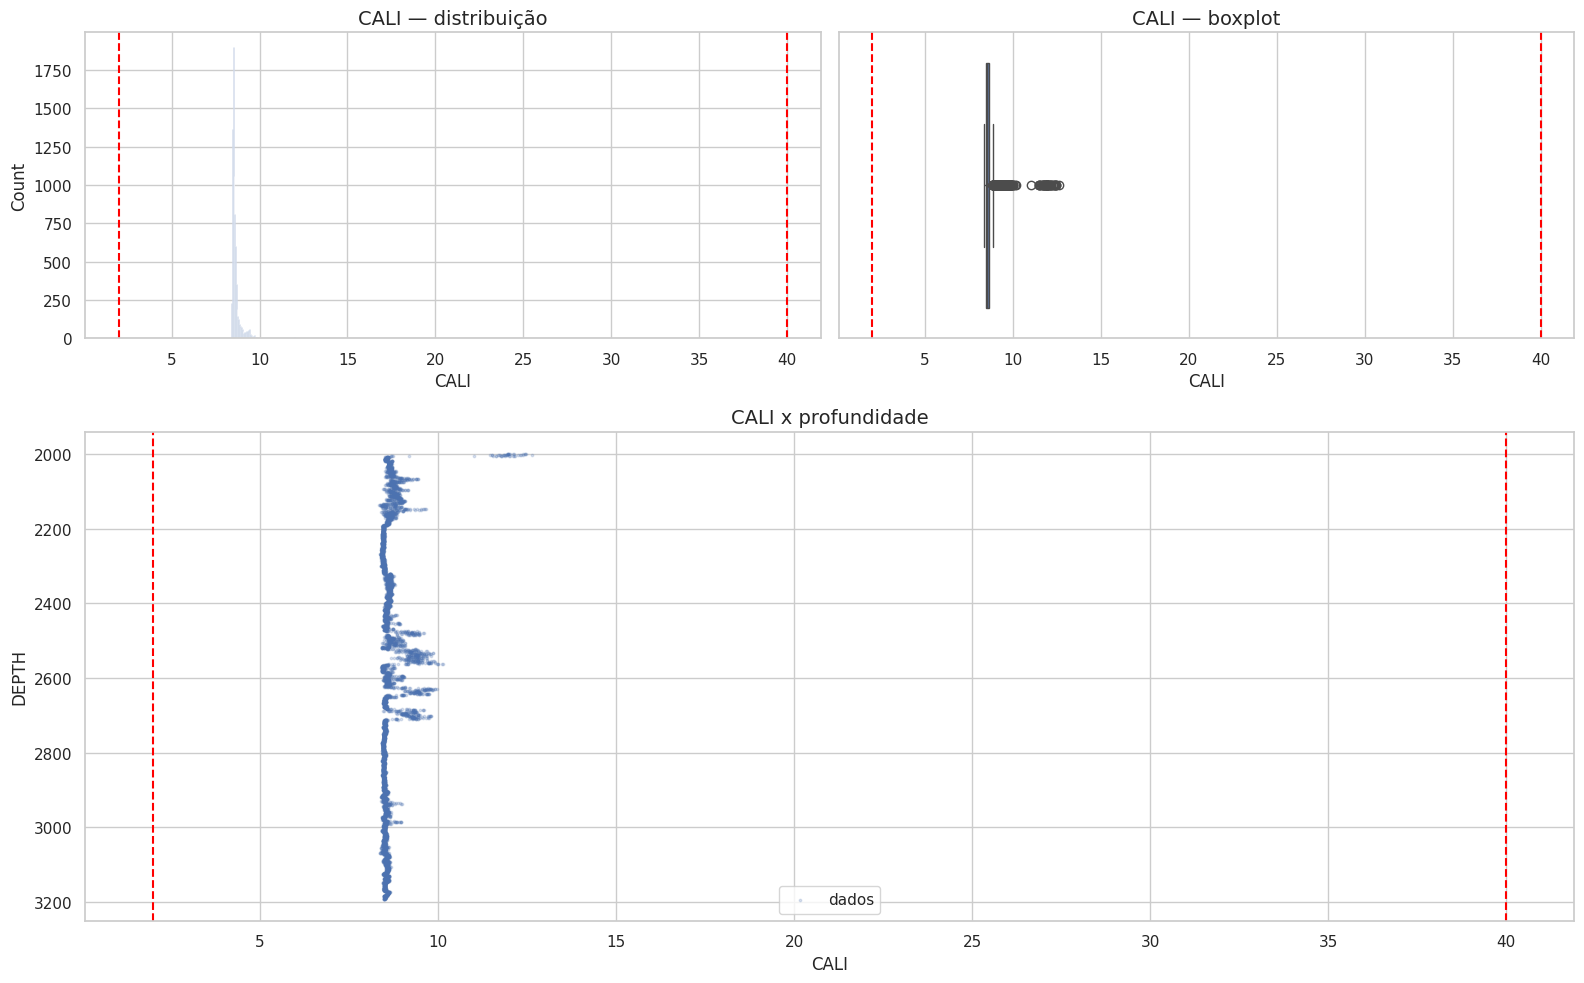

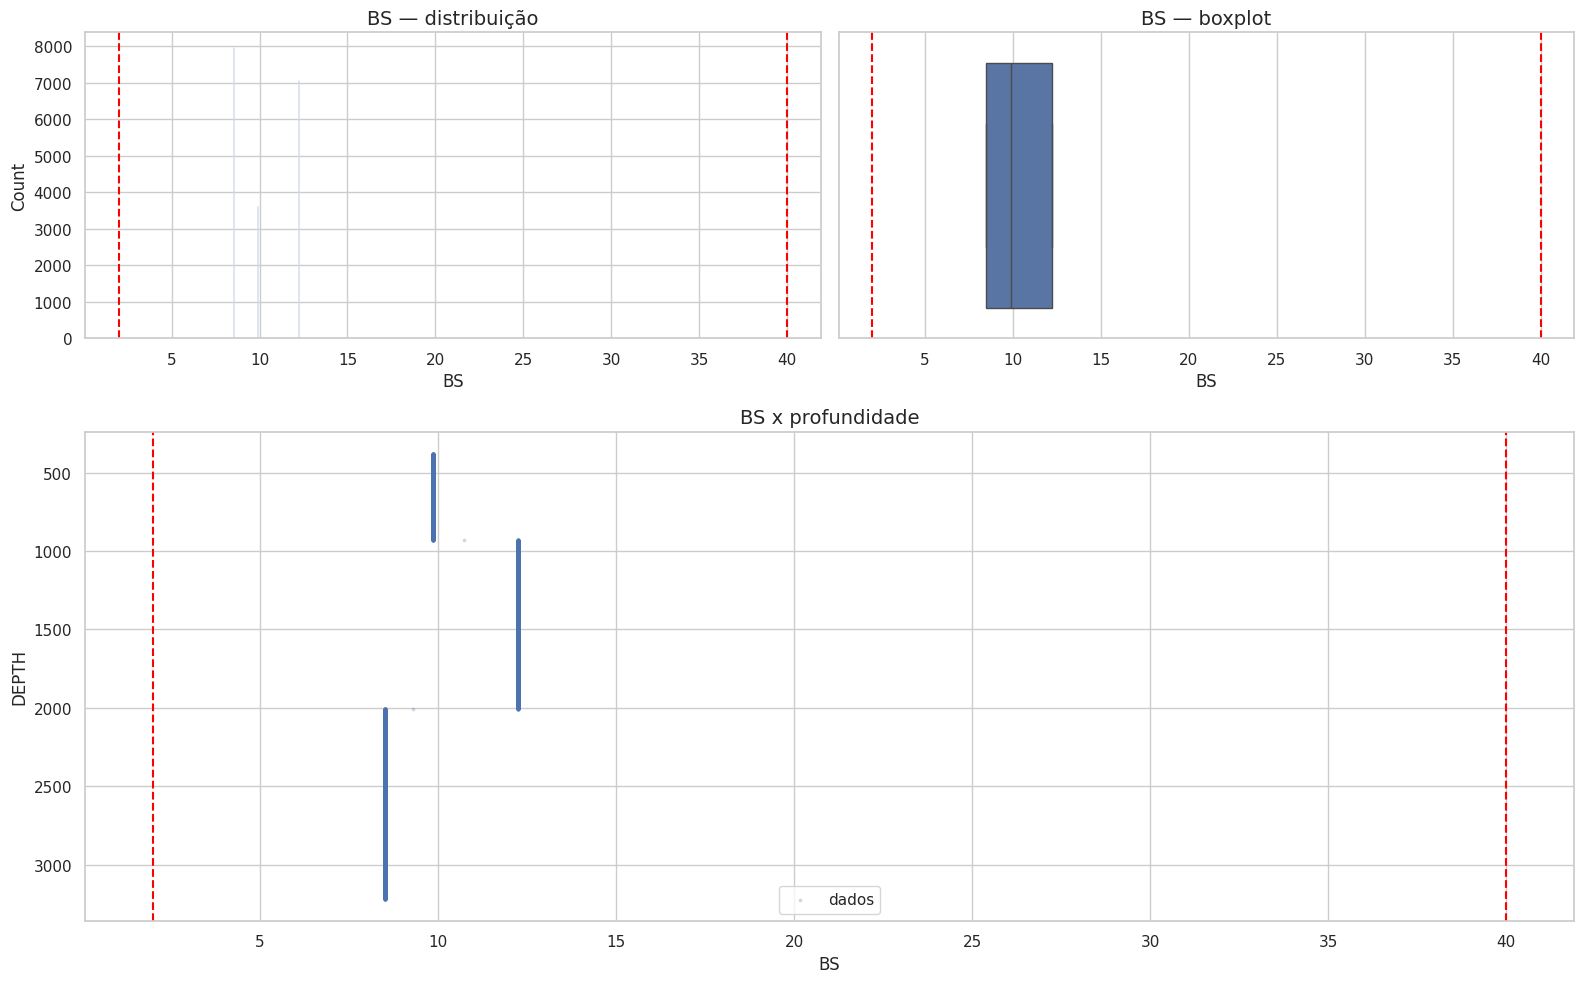

In [16]:
# ============================================================
# STEP 11.1 — GRÁFICOS DE QC FÍSICO
# ============================================================

def plot_curve_physical_qc(df: pd.DataFrame, curve: str, rules: Dict[str, Dict[str, object]], depth_col: str = "DEPTH") -> None:
    if curve not in df.columns or curve not in rules:
        return
    rule = rules[curve]
    min_v = float(rule["min"])
    max_v = float(rule["max"])
    plot_df = df[[depth_col, curve]].dropna().copy()
    if plot_df.empty:
        return
    suspicious_col = f"FLAG_{curve}_SUSPICIOUS"
    suspicious = df.loc[plot_df.index, suspicious_col] if suspicious_col in df.columns else (plot_df[curve] < min_v) | (plot_df[curve] > max_v)
    strange_df = plot_df.loc[suspicious].copy()

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.6])

    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(plot_df[curve], bins=100, ax=ax1)
    if not strange_df.empty:
        sns.histplot(strange_df[curve], bins=40, color="red", alpha=0.45, ax=ax1)
    ax1.axvline(min_v, color="red", linestyle="--")
    ax1.axvline(max_v, color="red", linestyle="--")
    ax1.set_title(f"{curve} — distribuição")

    ax2 = fig.add_subplot(gs[0, 1])
    sns.boxplot(x=plot_df[curve], ax=ax2)
    ax2.axvline(min_v, color="red", linestyle="--")
    ax2.axvline(max_v, color="red", linestyle="--")
    ax2.set_title(f"{curve} — boxplot")

    ax3 = fig.add_subplot(gs[1, :])
    ax3.scatter(plot_df[curve], plot_df[depth_col], s=3, alpha=0.20, label="dados")
    if not strange_df.empty:
        ax3.scatter(strange_df[curve], strange_df[depth_col], s=14, color="red", alpha=0.80, label="suspeitos")
    ax3.axvline(min_v, color="red", linestyle="--")
    ax3.axvline(max_v, color="red", linestyle="--")
    ax3.invert_yaxis()
    ax3.set_title(f"{curve} x profundidade")
    ax3.set_xlabel(curve)
    ax3.set_ylabel(depth_col)
    ax3.legend(loc="best")
    plt.tight_layout()
    plt.show()

for curve in ["GR", "RHOB", "DTC", "DTS", "NPOR", "RDEP", "RMED", "RSHA", "CALI", "BS"]:
    plot_curve_physical_qc(qc_df, curve, PHYSICAL_RULES, "DEPTH")

# STEP 12 — Outlier Investigation

Investigamos outliers por IQR e robust z-score. Isso adiciona flags, mas não remove automaticamente.

,CURVE,Q1,Q3,IQR,IQR_LOW_LIMIT,IQR_HIGH_LIMIT,OUTLIER_COUNT,OUTLIER_RATE
0,GR,72.368660,100.472012,28.103352,30.213633,142.627039,1197,0.063905
1,RHOB,2.356557,2.518349,0.161791,2.113870,2.761036,71,0.003791
2,DTC,83.164452,148.459099,65.294647,-14.777519,246.401070,0,0.000000
3,DTS,154.378006,378.433235,224.055229,-181.704838,714.516079,0,0.000000
4,NPOR,0.239417,0.327477,0.088060,0.107326,0.459567,221,0.011799
5,RDEP,0.962309,3.237903,2.275594,-2.451083,6.651295,602,0.032139
6,RMED,0.942606,3.178944,2.236338,-2.411900,6.533450,609,0.032513
7,CALI,8.485698,8.642059,0.156361,8.251156,8.876600,927,0.049490
8,BS,8.500000,12.250001,3.750001,2.874999,17.875002,0,0.000000


,CURVE,MEDIAN,MAD,THRESHOLD,OUTLIER_COUNT,OUTLIER_RATE,STATUS
0,GR,89.986179,13.331371,3.500000,721,0.038492,OK
1,RHOB,2.432674,0.082209,3.500000,61,0.003257,OK
2,DTC,103.830116,29.220772,3.500000,0,0.000000,OK
3,DTS,245.879082,104.084106,3.500000,0,0.000000,OK
4,NPOR,0.289869,0.042652,3.500000,101,0.005392,OK
5,RDEP,1.429376,0.776291,3.500000,1297,0.069244,OK
6,RMED,1.405266,0.771556,3.500000,1124,0.060007,OK
7,CALI,8.536774,0.063383,3.500000,949,0.050665,OK
8,BS,9.875000,1.375000,3.500000,0,0.000000,OK


,WELL,DEPTH,QC_FLAG_COUNT,FLAG_GR_LOW,FLAG_GR_HIGH,FLAG_GR_ZERO,FLAG_GR_SUSPICIOUS,FLAG_RHOB_LOW,FLAG_RHOB_HIGH,FLAG_RHOB_ZERO,FLAG_RHOB_SUSPICIOUS,FLAG_DTC_LOW,FLAG_DTC_HIGH,FLAG_DTC_ZERO,FLAG_DTC_SUSPICIOUS,FLAG_DTS_LOW,FLAG_DTS_HIGH,FLAG_DTS_ZERO,FLAG_DTS_SUSPICIOUS,FLAG_NPOR_LOW,FLAG_NPOR_HIGH,FLAG_NPOR_ZERO,FLAG_NPOR_SUSPICIOUS,FLAG_RDEP_LOW,FLAG_RDEP_HIGH,FLAG_RDEP_ZERO,FLAG_RDEP_SUSPICIOUS,FLAG_RMED_LOW,FLAG_RMED_HIGH,FLAG_RMED_ZERO,FLAG_RMED_SUSPICIOUS,FLAG_CALI_LOW,FLAG_CALI_HIGH,FLAG_CALI_ZERO,FLAG_CALI_SUSPICIOUS,FLAG_BS_LOW,FLAG_BS_HIGH,FLAG_BS_ZERO,FLAG_BS_SUSPICIOUS,FLAG_GR_IQR_OUTLIER,FLAG_RHOB_IQR_OUTLIER,FLAG_DTC_IQR_OUTLIER,FLAG_DTS_IQR_OUTLIER,FLAG_NPOR_IQR_OUTLIER,FLAG_RDEP_IQR_OUTLIER,FLAG_RMED_IQR_OUTLIER,FLAG_CALI_IQR_OUTLIER,FLAG_BS_IQR_OUTLIER,FLAG_GR_ROBUST_Z_OUTLIER,FLAG_RHOB_ROBUST_Z_OUTLIER,FLAG_DTC_ROBUST_Z_OUTLIER,FLAG_DTS_ROBUST_Z_OUTLIER,FLAG_NPOR_ROBUST_Z_OUTLIER,FLAG_RDEP_ROBUST_Z_OUTLIER,FLAG_RMED_ROBUST_Z_OUTLIER,FLAG_CALI_ROBUST_Z_OUTLIER,FLAG_BS_ROBUST_Z_OUTLIER
198,TFT-4,402.104400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
199,TFT-4,402.256400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
200,TFT-4,402.408400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
201,TFT-4,402.560400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
202,TFT-4,402.712400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
203,TFT-4,402.864400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
204,TFT-4,403.016400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
205,TFT-4,403.168400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
206,TFT-4,403.320400,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

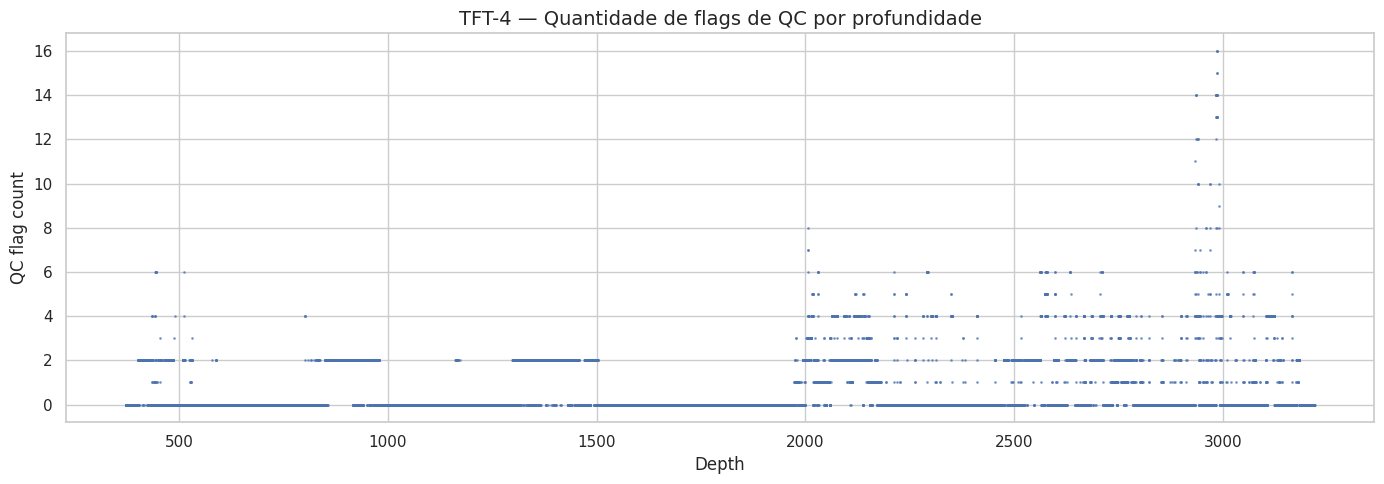

In [17]:
# ============================================================
# STEP 12 — OUTLIER INVESTIGATION
# ============================================================

def add_iqr_outlier_flags(df: pd.DataFrame, curves: List[str]):
    out = df.copy()
    rows = []
    for curve in curves:
        if curve not in out.columns:
            continue
        s = out[curve].dropna()
        if s.empty:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        flag = out[curve].notna() & ((out[curve] < low) | (out[curve] > high))
        out[f"FLAG_{curve}_IQR_OUTLIER"] = flag
        rows.append({"CURVE": curve, "Q1": q1, "Q3": q3, "IQR": iqr, "IQR_LOW_LIMIT": low, "IQR_HIGH_LIMIT": high, "OUTLIER_COUNT": int(flag.sum()), "OUTLIER_RATE": float(flag.mean())})
    return out, pd.DataFrame(rows)


def add_robust_zscore_flags(df: pd.DataFrame, curves: List[str], threshold: float = 3.5):
    out = df.copy()
    rows = []
    for curve in curves:
        if curve not in out.columns:
            continue
        s = out[curve]
        valid = s.dropna()
        if valid.empty:
            continue
        median = valid.median()
        mad = np.median(np.abs(valid - median))
        if mad == 0 or np.isnan(mad):
            out[f"ROBUST_Z_{curve}"] = np.nan
            out[f"FLAG_{curve}_ROBUST_Z_OUTLIER"] = False
            status, count, rate = "MAD_ZERO_OR_NAN", 0, 0
        else:
            robust_z = 0.6745 * (s - median) / mad
            flag = robust_z.abs() > threshold
            out[f"ROBUST_Z_{curve}"] = robust_z
            out[f"FLAG_{curve}_ROBUST_Z_OUTLIER"] = flag.fillna(False)
            status, count, rate = "OK", int(flag.sum()), float(flag.mean())
        rows.append({"CURVE": curve, "MEDIAN": median, "MAD": mad, "THRESHOLD": threshold, "OUTLIER_COUNT": count, "OUTLIER_RATE": rate, "STATUS": status})
    return out, pd.DataFrame(rows)

curves_for_outlier = [c for c in ["GR", "RHOB", "DTC", "DTS", "NPOR", "RDEP", "RMED", "RSHA", "CALI", "BS"] if c in qc_df.columns]
qc_df, iqr_summary_df = add_iqr_outlier_flags(qc_df, curves_for_outlier)
qc_df, robust_summary_df = add_robust_zscore_flags(qc_df, curves_for_outlier)

display(iqr_summary_df)
display(robust_summary_df)
iqr_summary_df.to_csv(REPORT_DIR / f"{WELL_NAME}_iqr_outlier_summary.csv", index=False)
robust_summary_df.to_csv(REPORT_DIR / f"{WELL_NAME}_robust_z_outlier_summary.csv", index=False)

flag_cols = [c for c in qc_df.columns if c.startswith("FLAG_")]
qc_df["QC_FLAG_COUNT"] = qc_df[flag_cols].sum(axis=1)
qc_df["QC_HAS_ANY_FLAG"] = qc_df["QC_FLAG_COUNT"] > 0

display(qc_df.loc[qc_df["QC_HAS_ANY_FLAG"], ["WELL", "DEPTH", "QC_FLAG_COUNT"] + flag_cols].head(100))

plt.figure(figsize=(14, 5))
plt.plot(qc_df["DEPTH"], qc_df["QC_FLAG_COUNT"], ".", markersize=2, alpha=0.6)
plt.title(f"{WELL_NAME} — Quantidade de flags de QC por profundidade")
plt.xlabel("Depth")
plt.ylabel("QC flag count")
plt.tight_layout()
plt.show()

# STEP 13 — Geological Consistency Check

Criamos flags interpretativas simples: washout, rocha limpa, shale, zona limpa e resistiva, RHOB suspeito com washout, DTC/DTS altos.

In [18]:
# ============================================================
# STEP 13 — GEOLOGICAL CONSISTENCY CHECK
# ============================================================

geo_df = qc_df.copy()

if {"CALI", "BS"}.issubset(geo_df.columns):
    geo_df["DCALC"] = geo_df["CALI"] - geo_df["BS"]
    geo_df["FLAG_WASHOUT_DCALC_GT_1IN"] = geo_df["DCALC"].notna() & (geo_df["DCALC"] > 1.0)
else:
    geo_df["DCALC"] = np.nan
    geo_df["FLAG_WASHOUT_DCALC_GT_1IN"] = False

if "GR" in geo_df.columns:
    geo_df["FLAG_CLEAN_ROCK_GR_LOW"] = geo_df["GR"].notna() & (geo_df["GR"] < 50)
    geo_df["FLAG_SHALEY_GR_HIGH"] = geo_df["GR"].notna() & (geo_df["GR"] > 120)
else:
    geo_df["FLAG_CLEAN_ROCK_GR_LOW"] = False
    geo_df["FLAG_SHALEY_GR_HIGH"] = False

if {"GR", "RDEP"}.issubset(geo_df.columns):
    geo_df["FLAG_CLEAN_RESISTIVE_ZONE"] = (
        geo_df["GR"].notna()
        & geo_df["RDEP"].notna()
        & (geo_df["GR"] < 70)
        & (geo_df["RDEP"] > geo_df["RDEP"].quantile(0.75))
    )
else:
    geo_df["FLAG_CLEAN_RESISTIVE_ZONE"] = False

if "FLAG_RHOB_SUSPICIOUS" in geo_df.columns:
    geo_df["FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT"] = geo_df["FLAG_RHOB_SUSPICIOUS"] & geo_df["FLAG_WASHOUT_DCALC_GT_1IN"]
else:
    geo_df["FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT"] = False

if {"DTC", "DTS"}.issubset(geo_df.columns):
    geo_df["FLAG_HIGH_DTC_HIGH_DTS"] = (
        geo_df["DTC"].notna()
        & geo_df["DTS"].notna()
        & (geo_df["DTC"] > geo_df["DTC"].quantile(0.90))
        & (geo_df["DTS"] > geo_df["DTS"].quantile(0.90))
    )
else:
    geo_df["FLAG_HIGH_DTC_HIGH_DTS"] = False

geo_flag_cols = [
    "FLAG_WASHOUT_DCALC_GT_1IN",
    "FLAG_CLEAN_ROCK_GR_LOW",
    "FLAG_SHALEY_GR_HIGH",
    "FLAG_CLEAN_RESISTIVE_ZONE",
    "FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT",
    "FLAG_HIGH_DTC_HIGH_DTS",
]

geo_summary_df = geo_df[geo_flag_cols].sum().rename("COUNT").to_frame()
geo_summary_df["RATE"] = geo_summary_df["COUNT"] / len(geo_df)
display(geo_summary_df)
geo_summary_df.to_csv(REPORT_DIR / f"{WELL_NAME}_geological_consistency_summary.csv")

,COUNT,RATE
FLAG_WASHOUT_DCALC_GT_1IN,142,0.007581
FLAG_CLEAN_ROCK_GR_LOW,1303,0.069564
FLAG_SHALEY_GR_HIGH,1139,0.060808
FLAG_CLEAN_RESISTIVE_ZONE,917,0.048956
FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT,0,0.000000
FLAG_HIGH_DTC_HIGH_DTS,852,0.045486


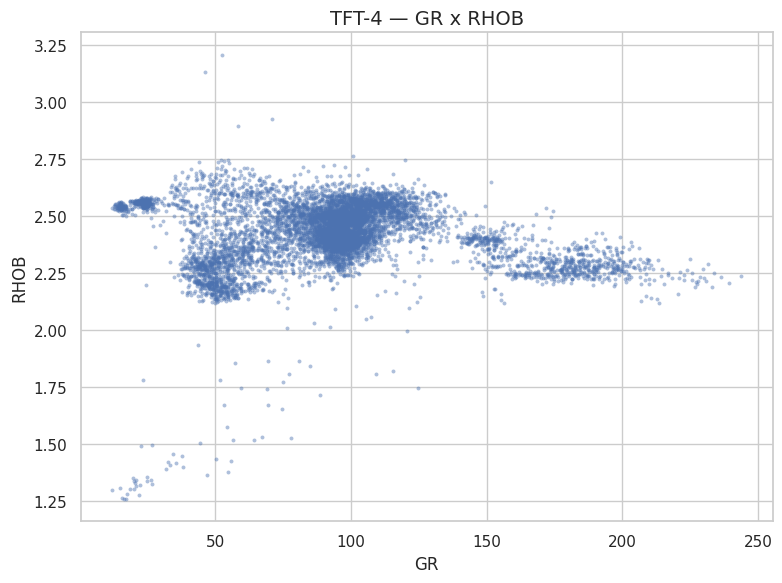

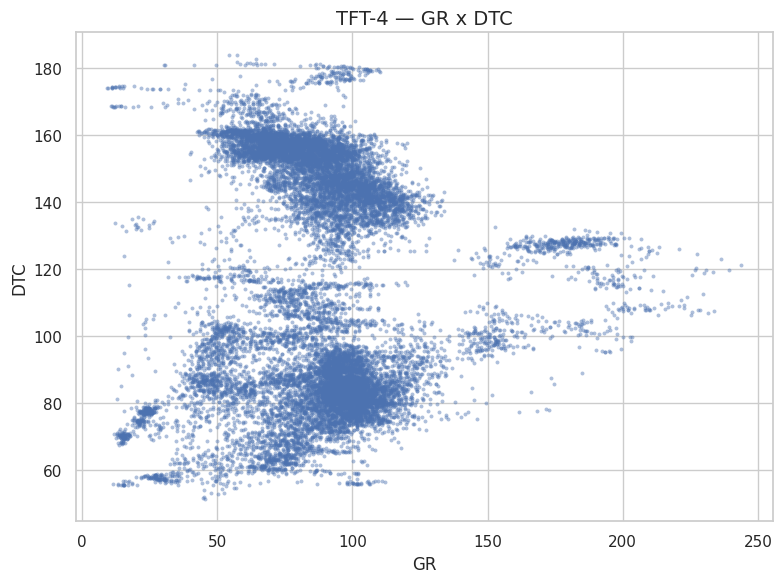

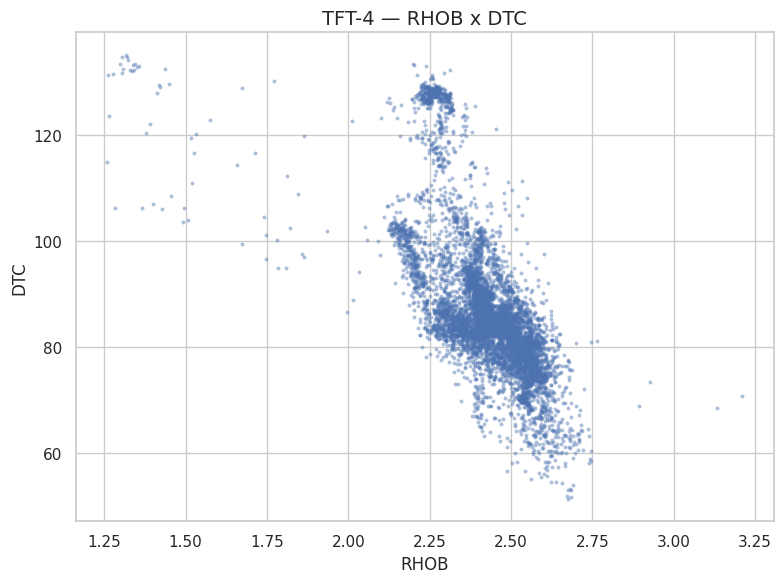

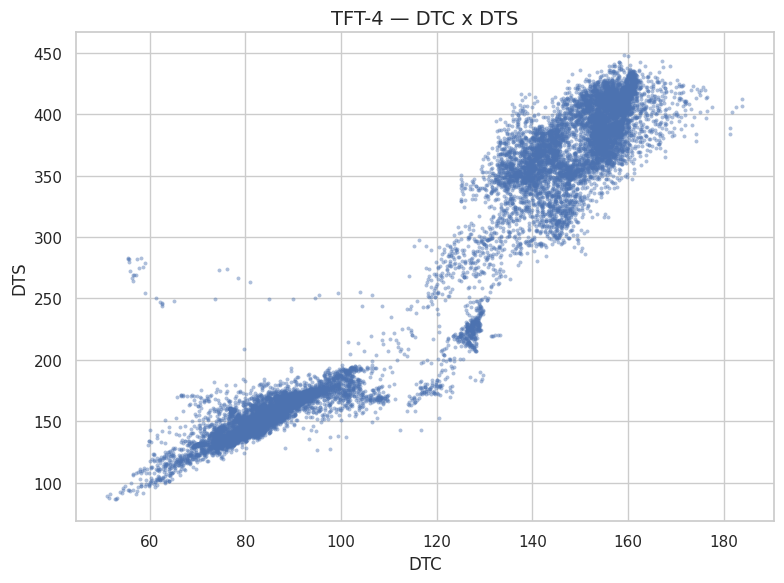

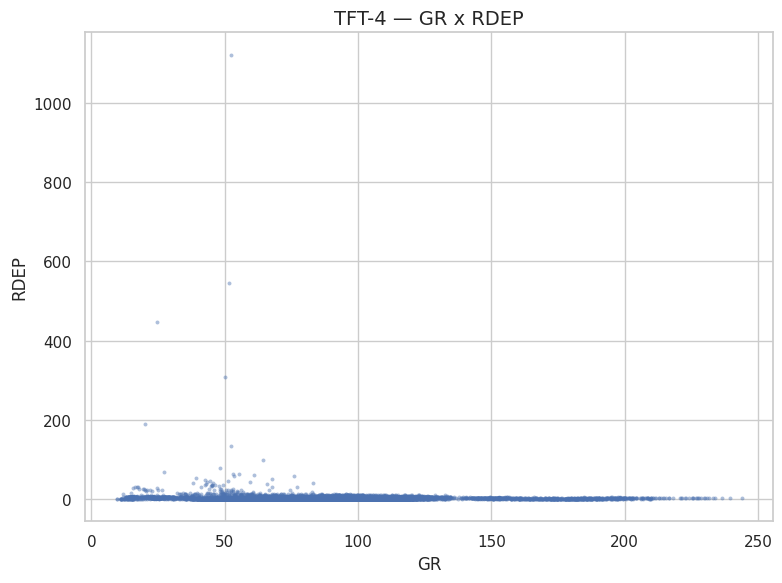

In [19]:
# ============================================================
# STEP 13.1 — CROSSPLOTS GEOLÓGICOS
# ============================================================

def crossplot(df: pd.DataFrame, x: str, y: str, title: Optional[str] = None) -> None:
    if x not in df.columns or y not in df.columns:
        print(f"Ignorando crossplot: {x} ou {y} não existe.")
        return
    plot_df = df[[x, y]].dropna().copy()
    if plot_df.empty:
        print(f"Sem dados para {x} x {y}")
        return
    if len(plot_df) > 50_000:
        plot_df = plot_df.sample(50_000, random_state=42)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x=x, y=y, s=8, alpha=0.45, linewidth=0)
    plt.title(title or f"{x} x {y}")
    plt.tight_layout()
    plt.show()

crossplot(geo_df, "GR", "RHOB", f"{WELL_NAME} — GR x RHOB")
crossplot(geo_df, "GR", "DTC", f"{WELL_NAME} — GR x DTC")
crossplot(geo_df, "RHOB", "DTC", f"{WELL_NAME} — RHOB x DTC")
if "DTS" in geo_df.columns:
    crossplot(geo_df, "DTC", "DTS", f"{WELL_NAME} — DTC x DTS")
if "RDEP" in geo_df.columns:
    crossplot(geo_df, "GR", "RDEP", f"{WELL_NAME} — GR x RDEP")

# STEP 14 — Export Curated Parquet

Salvamos a camada **curated**:

```text
data/curated/parquet/single_well_qc/
```

Esta camada contém dados padronizados, flags de QC e flags geológicas simples. A engenharia de atributos fica no próximo notebook.

In [20]:
# ============================================================
# STEP 14 — EXPORT CURATED PARQUET
# ============================================================

safe_well_name = WELL_NAME.replace("/", "_").replace(" ", "_")

preferred_order = [
    "WELL", "DEPTH",
    "GR", "RHOB", "DTC", "DTS", "NPOR",
    "RDEP", "RMED", "RSHA", "CALI", "BS",
    "DCALC",
    "QC_FLAG_COUNT", "QC_HAS_ANY_FLAG",
]

existing_preferred = [c for c in preferred_order if c in geo_df.columns]
remaining_cols = [c for c in geo_df.columns if c not in existing_preferred]
curated_df = geo_df[existing_preferred + remaining_cols].copy()

if "WELL" in curated_df.columns:
    curated_df["WELL"] = curated_df["WELL"].astype("string")

bool_cols = [c for c in curated_df.columns if c.startswith("FLAG_") or curated_df[c].dtype == bool]
for col in bool_cols:
    curated_df[col] = curated_df[col].fillna(False).astype(bool)

curated_path = DATA_CURATED_DIR / f"{safe_well_name}_single_well_qc_curated.parquet"
curated_df.to_parquet(curated_path, index=False)

column_dictionary_df = pd.DataFrame({
    "COLUMN": curated_df.columns,
    "DTYPE": [str(curated_df[c].dtype) for c in curated_df.columns],
    "NON_NULL_COUNT": [curated_df[c].notna().sum() for c in curated_df.columns],
    "NULL_COUNT": [curated_df[c].isna().sum() for c in curated_df.columns],
    "FILL_RATE": [curated_df[c].notna().mean() for c in curated_df.columns],
})
column_dictionary_path = REPORT_DIR / f"{safe_well_name}_curated_column_dictionary.csv"
column_dictionary_df.to_csv(column_dictionary_path, index=False)

final_summary_df = pd.DataFrame([{
    "WELL": WELL_NAME,
    "SOURCE_FILE": selected_file.name,
    "CURATED_ROWS": len(curated_df),
    "CURATED_COLUMNS": curated_df.shape[1],
    "DEPTH_MIN": curated_df["DEPTH"].min(),
    "DEPTH_MAX": curated_df["DEPTH"].max(),
    "HAS_DTC": "DTC" in curated_df.columns and curated_df["DTC"].notna().any(),
    "HAS_DTS": "DTS" in curated_df.columns and curated_df["DTS"].notna().any(),
    "HAS_RHOB": "RHOB" in curated_df.columns and curated_df["RHOB"].notna().any(),
    "HAS_GR": "GR" in curated_df.columns and curated_df["GR"].notna().any(),
    "CURATED_PARQUET": str(curated_path),
}])
summary_path = REPORT_DIR / f"{safe_well_name}_curated_summary.csv"
final_summary_df.to_csv(summary_path, index=False)

print("CURATED PARQUET EXPORTADO COM SUCESSO!")
print(f"Arquivo: {curated_path}")
print(f"Dicionário: {column_dictionary_path}")
print(f"Resumo: {summary_path}")
display(final_summary_df)
display(column_dictionary_df)

CURATED PARQUET EXPORTADO COM SUCESSO!
Arquivo: ../data/curated/parquet/single_well_qc/TFT-4_single_well_qc_curated.parquet
Dicionário: ../reports/single_well_qc/TFT-4_curated_column_dictionary.csv
Resumo: ../reports/single_well_qc/TFT-4_curated_summary.csv


,WELL,SOURCE_FILE,CURATED_ROWS,CURATED_COLUMNS,DEPTH_MIN,DEPTH_MAX,HAS_DTC,HAS_DTS,HAS_RHOB,HAS_GR,CURATED_PARQUET
0,TFT-4,TFT-4.las,18731,92,372.008400,"3,218.968400",True,True,True,True,../data/curated/parquet/single_well_qc/TFT-4_s...


,COLUMN,DTYPE,NON_NULL_COUNT,NULL_COUNT,FILL_RATE
0,WELL,string,18731,0,1.000000
1,DEPTH,float64,18731,0,1.000000
2,GR,float64,18666,65,0.996530
3,RHOB,float64,7800,10931,0.416422
4,DTC,float64,18199,532,0.971598
5,DTS,float64,15252,3479,0.814265
6,NPOR,float64,7835,10896,0.418291
7,RDEP,float64,18567,164,0.991244
8,RMED,float64,18524,207,0.988949
9,CALI,float64,7842,10889,0.418664


# Fim do Notebook 01

Resultado produzido:

```text
data/curated/parquet/single_well_qc/
```

Próximo notebook:

```text
02_single_well_feature_engineering.ipynb
```